## Analysis of Deconvolution Method Results

In this section, we analyze the results obtained from a panel of deconvolution methods. The tables of predicted cell subtype abundance obtained from our panel of methods are loaded from the notebook `Fig3_2_deconvolution_panel.ipynb`. Additionally, we load true proportions from the same folder, allowing us to compute four metrics: Pearson correlation coefficient (PCC), Spearman correlation coefficient (SCC), root mean square error (RMSE), and R-square (R2). The analysis is performed on a per-bulk basis, comparing predicted and true cell subtype abundances for each bulk, resulting in N accuracy values for N bulks in a given experiment.

We present the results for 12 different analyses, each associated with a specific cancer type:

- Mixed Leukemic Cell Lines (AML): In-vitro experiment with directly sequenced cell mixtures, where true cell line proportions were recorded as ground truth.
- Van Galen > Naldini (AML): Cross-dataset pseudo-bulk analysis using Van Galen scRNA-seq dataset as a reference to deconvolute Naldini pseudo-bulks.
- Naldini > Van Galen (AML): Cross-dataset pseudo-bulk analysis using Naldini scRNA-seq dataset as a reference to deconvolute Van Galen pseudo-bulks.
- 200 Simulated Bulks (AML): Analysis of 200 simulated bulks generated from the Van Galen scRNA-seq dataset.
- Lee > Khaliq (CRC): Cross-dataset pseudo-bulk analysis using Lee scRNA-seq dataset as a reference to deconvolute Khaliq pseudo-bulks.
- Khaliq > Lee (CRC): Cross-dataset pseudo-bulk analysis using Khaliq scRNA-seq dataset as a reference to deconvolute Lee pseudo-bulks.
- Jerby > Tirosh (Melanoma): Cross-dataset pseudo-bulk analysis using Jerby scRNA-seq dataset as a reference to deconvolute Tirosh pseudo-bulks.
- Tirosh > Jerby (Melanoma): Cross-dataset pseudo-bulk analysis using Tirosh scRNA-seq dataset as a reference to deconvolute Jerby pseudo-bulks.
- Wu > Gray (Breast Cancer): Cross-dataset pseudo-bulk analysis using Wu scRNA-seq dataset as a reference to deconvolute Gray pseudo-bulks.
- Gray > Wu (Breast Cancer): Cross-dataset pseudo-bulk analysis using Gray scRNA-seq dataset as a reference to deconvolute Wu pseudo-bulks.
- Neftel (10X) > Neftel (SmartSeq2) (GBM): Cross-technology pseudo-bulk analysis using Neftel scRNA-seq dataset (10X) as a reference to deconvolute Neftel scRNA-seq dataset (SmartSeq2).
- Neftel (SmartSeq2) > Neftel (10X) (GBM): Cross-technology pseudo-bulk analysis using Neftel scRNA-seq dataset (SmartSeq2) as a reference to deconvolute Neftel scRNA-seq dataset (10X).

In [2]:
# Load required libraries
library(ggplot2) ; library(reshape2) ; library(ggpubr) ; library(matrixStats)
library(circlize) ; library(RColorBrewer) ; library(ggpmisc)

### Functions 

In [13]:
source("shared_functions.R")

# METRICS FUNCTIONS
### Function to retrieve all metrics from Deconvolution vs True cell-type proportion comparison
### Function for each deconvolution methods ###                                                                                      
load_all_props <- function(odir, include_cibersortx=FALSE){
    tdir = paste0(odir,'/tmp_tabs')
    true_p = read.csv(paste0(odir, '/true_prop.csv'), row.names='X')
    sample_names = row.names(true_p)
    celltype_names = read.csv(paste0(odir, '/celltype_names.csv'))$x
    climb_p = read.csv(paste0(odir, '/climb_prop.csv'), row.names='X')[,celltype_names]
    #climb_dw_p = read.csv(paste0(odir, '/climb_dw_prop.csv'), row.names='X')[,celltype_names]
    bayesprism_p = read.csv(paste0(odir, '/bayesprism_prop.csv'), row.names='X')[,celltype_names]
    music_p = read.csv(paste0(odir, '/music_prop.csv'), row.names='X')[,celltype_names]
    nnls_p = read.csv(paste0(odir, '/nnls_prop.csv'), row.names='X')[,celltype_names]
    rand_p = read.csv(paste0(odir, '/rand_prop.csv'), row.names='X')[,celltype_names]
    bisque_p = read.csv(paste0(odir, '/bisque_prop.csv'), row.names='X')[,celltype_names]
    tape_p = load_tape_prop(tdir, odir, celltype_names)
    scaden_p = load_scaden_prop(tdir, odir, celltype_names)
    if(include_cibersortx){
        csx_p = add_missing_celltypes(read.csv(paste0(odir, '/cibersortx_prop.csv'), row.names='Mixture'), celltype_names)[,celltype_names]
        all_p = list(as.matrix(climb_p), as.matrix(scaden_p), 
                     as.matrix(tape_p), as.matrix(csx_p), as.matrix(bayesprism_p), as.matrix(music_p), 
                     as.matrix(nnls_p), as.matrix(bisque_p), as.matrix(rand_p))
        names(all_p) = c('CLIMB', 'Scaden', 'TAPE', 'CiberSortX', 'BayesPrism', 'MuSiC', 'NNLS', 'BisqueRNA', 'Random')
    } else {
        all_p = list(as.matrix(climb_p), as.matrix(scaden_p), 
                     as.matrix(tape_p), as.matrix(bayesprism_p), as.matrix(music_p), 
                     as.matrix(nnls_p), as.matrix(bisque_p), as.matrix(rand_p))
        names(all_p) = c('CLIMB', 'Scaden', 'TAPE', 'BayesPrism', 'MuSiC', 'NNLS', 'BisqueRNA', 'Random')
    }
    true_prop_cols = colnames(true_p) ; true_prop_rows = rownames(true_p)
    message(paste0('Checking that all tables have the same cell-type labels: ',suppressWarnings(all(lapply(all_p, function(x) all(colnames(x) == true_prop_cols))))))
    message(paste0('Checking that all tables has the same sample names: ',suppressWarnings(all(lapply(all_p, function(x) all(rownames(x) == true_prop_rows))))))
    return(all_p)
}  
gene_intersection <- function(dataset1, dataset2){
    message('Finding gene intersect between two datasets')
    gene_intersect = intersect(rownames(dataset1), rownames(dataset2))
    message(paste0(length(gene_intersect), ' genes in common between two datasets. Subsetting datasets.'))
    return(gene_intersect)
}
generate_comp_plot <- function(obj.res, type.err=1){
    #type.err , 1=pcor, 2=scor, 3=r_square, 4=rmse
    type.err.l = list('PCC', 'SCC', 'R2', 'RMSE')
    methods = c('MuSiC', 'NNLS', 'CLIMB', 'TAPE', 'Scaden', 'Bisque', 'Random', 'BayesPrism', 'CiberSortX')
    df_scor = data.frame(cbind(obj.res$MuSiC[[type.err]], obj.res$NNLS[[type.err]], 
                               obj.res$CLIMB[[type.err]], obj.res$TAPE[[type.err]], obj.res$Scaden[[type.err]],
                               obj.res$BisqueRNA[[type.err]], obj.res$Random[[type.err]], obj.res$BayesPrism[[type.err]], 
                               obj.res$CiberSortX[[type.err]]))
    colnames(df_scor) = methods
    levels_ = colnames(df_scor)[rev(order(colMedians(as.matrix(df_scor), na.rm = T)))]
    if(grepl('RMSE', type.err)){levels_ = rev(levels_)}
    df_scor_m = data.frame(reshape2::melt(df_scor))
    df_scor_m$variable = factor(df_scor_m$variable, levels = levels_) 
    g_rows = ggplot(data=df_scor_m, aes(x=variable, y=value, color=variable)) + 
                geom_boxplot(outlier.shape = NA) + 
                #geom_point(aes(x=variable, y=value, color=variable), position_jitter(w=0, h = 0)) + 
                geom_jitter(width=0.3, height=0.0) +
                theme_classic() +
                scale_color_manual(values=ifelse(grepl('CLIMB', levels_), 'darkred', 'grey38')) + 
                theme(legend.position="none", axis.text.x = element_text(angle = 45, hjust=1.0, vjust=1.0)) +
                xlab('') + ylab(gsub('_per.*','',type.err)) #+ coord_flip() # ylab(expression(pa
    return(g_rows)
}
generate_comp_plot_ <- function(obj.res, type.err=1){
    #type.err , 1=pcor, 2=scor, 3=r_square, 4=rmse
    type.err.l = list('PCC', 'SCC', 'R2', 'RMSE')
    methods = c('MuSiC', 'NNLS', 'CLIMB', 'TAPE', 'Scaden', 'Bisque', 'Random', 'BayesPrism')
    df_scor = data.frame(cbind(obj.res$MuSiC[[type.err]], obj.res$NNLS[[type.err]], 
                               obj.res$CLIMB[[type.err]], obj.res$TAPE[[type.err]], obj.res$Scaden[[type.err]],
                               obj.res$BisqueRNA[[type.err]], obj.res$Random[[type.err]], obj.res$BayesPrism[[type.err]]))
    colnames(df_scor) = methods
    levels_ = colnames(df_scor)[rev(order(colMedians(as.matrix(df_scor), na.rm = T)))]
    if(grepl('RMSE', type.err)){levels_ = rev(levels_)}
    df_scor_m = data.frame(reshape2::melt(df_scor))
    df_scor_m$variable = factor(df_scor_m$variable, levels = levels_) 
    g_rows = ggplot(data=df_scor_m, aes(x=variable, y=value, color=variable)) + 
                geom_boxplot(outlier.shape = NA) + 
                #geom_point(aes(x=variable, y=value, color=variable), position_jitter(w=0, h = 0)) + 
                geom_jitter(width=0.3, height=0.0) +
                theme_classic() +
                scale_color_manual(values=ifelse(grepl('CLIMB', levels_), 'darkred', 'grey38')) + 
                theme(legend.position="none", axis.text.x = element_text(angle = 45, hjust=1.0, vjust=1.0)) +
                xlab('') + ylab(gsub('_per.*','',type.err)) #+ coord_flip() # ylab(expression(pa
    return(g_rows)
}
                                                                                                      
make_all_metrics <- function(all_ps, t_prop_f){
    t_prop_fd = 
    t_prop = as.matrix(read.csv(t_prop_f, row.names = 'X'))
    all_rs = list()
    for(p in 1:length(all_ps)){
        name_p = names(all_ps)[p]
        all_rs[[name_p]] = suppressWarnings(comp_rows_and_cols(all_ps[[p]], t_prop))
        names(all_rs[[name_p]]) = c('PCC_per_sample', 'SCC_per_sample', 'R2_per_sample', 'RMSE_per_sample',
                                    'PCC_per_celltype', 'SCC_per_celltype', 'R2_per_celltype', 'RMSE_per_celltype',
                                    'PCC_overall', 'SCC_overall', 'R2_overall', 'RMSE_overall')
    }
    names(all_rs) = names(all_ps)
    return(all_rs)
}

rank_all_metrics <- function(tab){
    median_metrics=list()
    for(i in 1:4){
        median_metrics[[i]] = c(median(tab$CLIMB[[i]], na.rm = T), median(tab$Scaden[[i]], na.rm = T), #median(aml.na2na$CLIMB[[i]]), 
                        median(tab$TAPE[[i]], na.rm = T), median(tab$CiberSortX[[i]], na.rm = T), median(tab$BayesPrism[[i]], na.rm = T), median(tab$MuSiC[[i]], na.rm = T),
                        median(tab$NNLS[[i]], na.rm = T), median(tab$BisqueRNA[[i]], na.rm = T), median(tab$Random[[i]], na.rm = T))
    }
    names(median_metrics) = c('PCC', 'SCC', 'R2', 'RMSE')
    df_rank = data.frame(rank_rmse=rank(median_metrics$RMSE, na.last = T), rank_pcc=rank(-1*median_metrics$PCC, na.last = T),
                         rank_scc=rank(-1*median_metrics$SCC, na.last = T), rank_r2=rank(-1*median_metrics$R2, na.last = T))
    rownames(df_rank) = c('CLIMB', 'Scaden', 'TAPE', 'CiberSortX', 'BayesPrism', 'MuSiC', 'NNLS', 'BisqueRNA', 'Random')
    return(df_rank)
}

# In-vitro Experiment

Mixed Leukemic cell lines (AML): The in-vitro experiment performed in our laboratory, where true cell line proportions were recorded after cell counting. Cell mix were directly sequenced without co-culturing cells. We thus have cell counts for each line as a ground truth, and the results of deconvolution methods obtained through an actual bulk RNA-seq.

In [29]:
out_dir = 'data/invitro_experiment/tables_preproc/'
invitro = make_all_metrics(load_all_props(out_dir, include_cibersortx = T), paste0(out_dir, '/true_prop.csv'))

Checking that all tables have the same cell-type labels: TRUE

Checking that all tables has the same sample names: TRUE



No id variables; using all as measure variables

No id variables; using all as measure variables

No id variables; using all as measure variables

No id variables; using all as measure variables



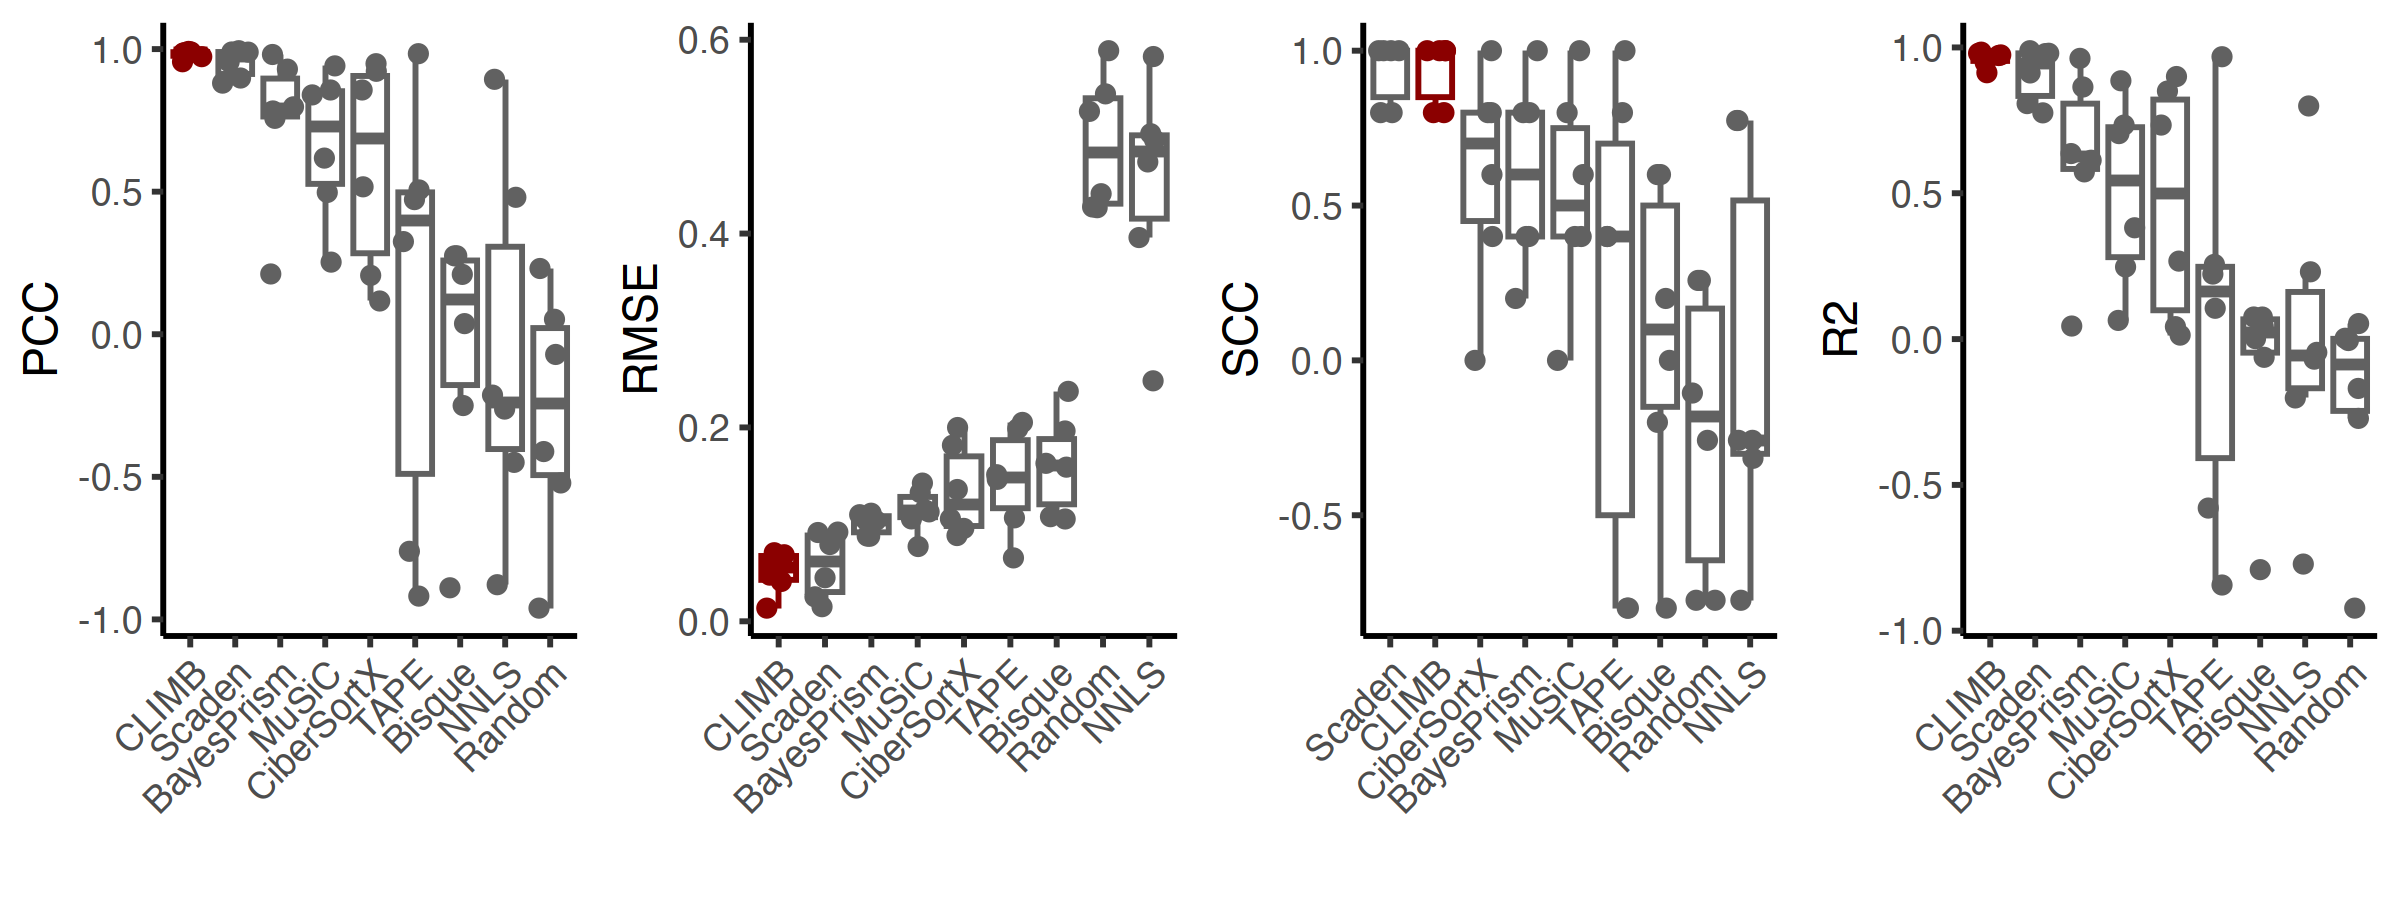

In [30]:
# Make figure by assembling 4 metric-related figures in one
g_pcc = generate_comp_plot(invitro, type.err='PCC_per_sample') # PCC
g_scc = generate_comp_plot(invitro, type.err='SCC_per_sample') # SCC
g_r2 = generate_comp_plot(invitro, type.err='R2_per_sample') # R-square
g_rmse = generate_comp_plot(invitro, type.err='RMSE_per_sample') # RMSE
options(repr.plot.width=8, repr.plot.height=3, repr.plot.res=300)
ggarrange(g_pcc, g_rmse, g_scc, g_r2, ncol=4, nrow=1)

Results for the in-vitro experiment are shown in more details in the notebook `Fig2_invitro_experiment.ipynb`

# AML cross-dataset deconvolution analysis

Here we will load 3 remaining analysis in AML context:
- Van Galen > Naldini (AML): Cross-dataset pseudo-bulk analysis where the scRNA-seq dataset from Van Galen was used as a reference to deconvolute the pseudo-bulks made from Naldini dataset, after data integration and transfering of cell subtype labels from Van Galen to Naldini.
- Naldini > Van Galen (AML): Cross-dataset pseudo-bulk analysis where the scRNA-seq dataset from Naldini was used as a reference to deconvolute the pseudo-bulks made from Van Galen dataset, after data integration and transfering of cell subtype labels from Naldini to Van Galen.
- 200 simulated bulks (AML): Simulated dataset of 200 bulks made from Van Galen scRNA-seq dataset.

In [23]:
aml.na2vg = make_all_metrics(load_all_props('data/pseudobulks_climb/AML_na2vg', include_cibersortx=T), 'data/pseudobulks_climb/AML_na2vg/true_prop.csv') #, include_cibersortx=T
aml.vg2na = make_all_metrics(load_all_props('data/pseudobulks_climb/AML_vg2na', include_cibersortx=T), 'data/pseudobulks_climb/AML_vg2na/true_prop.csv')
aml.vg2na_200sim =  make_all_metrics(load_all_props('data/simulation_aml/tables_vg2na/', include_cibersortx=T), 'data/simulation_aml/tables_vg2na/true_prop.csv')

Checking that all tables have the same cell-type labels: TRUE

Checking that all tables has the same sample names: TRUE

Checking that all tables have the same cell-type labels: TRUE

Checking that all tables has the same sample names: TRUE

Checking that all tables have the same cell-type labels: TRUE

Checking that all tables has the same sample names: TRUE



## Plot the comparative results 

No id variables; using all as measure variables

No id variables; using all as measure variables

No id variables; using all as measure variables

No id variables; using all as measure variables



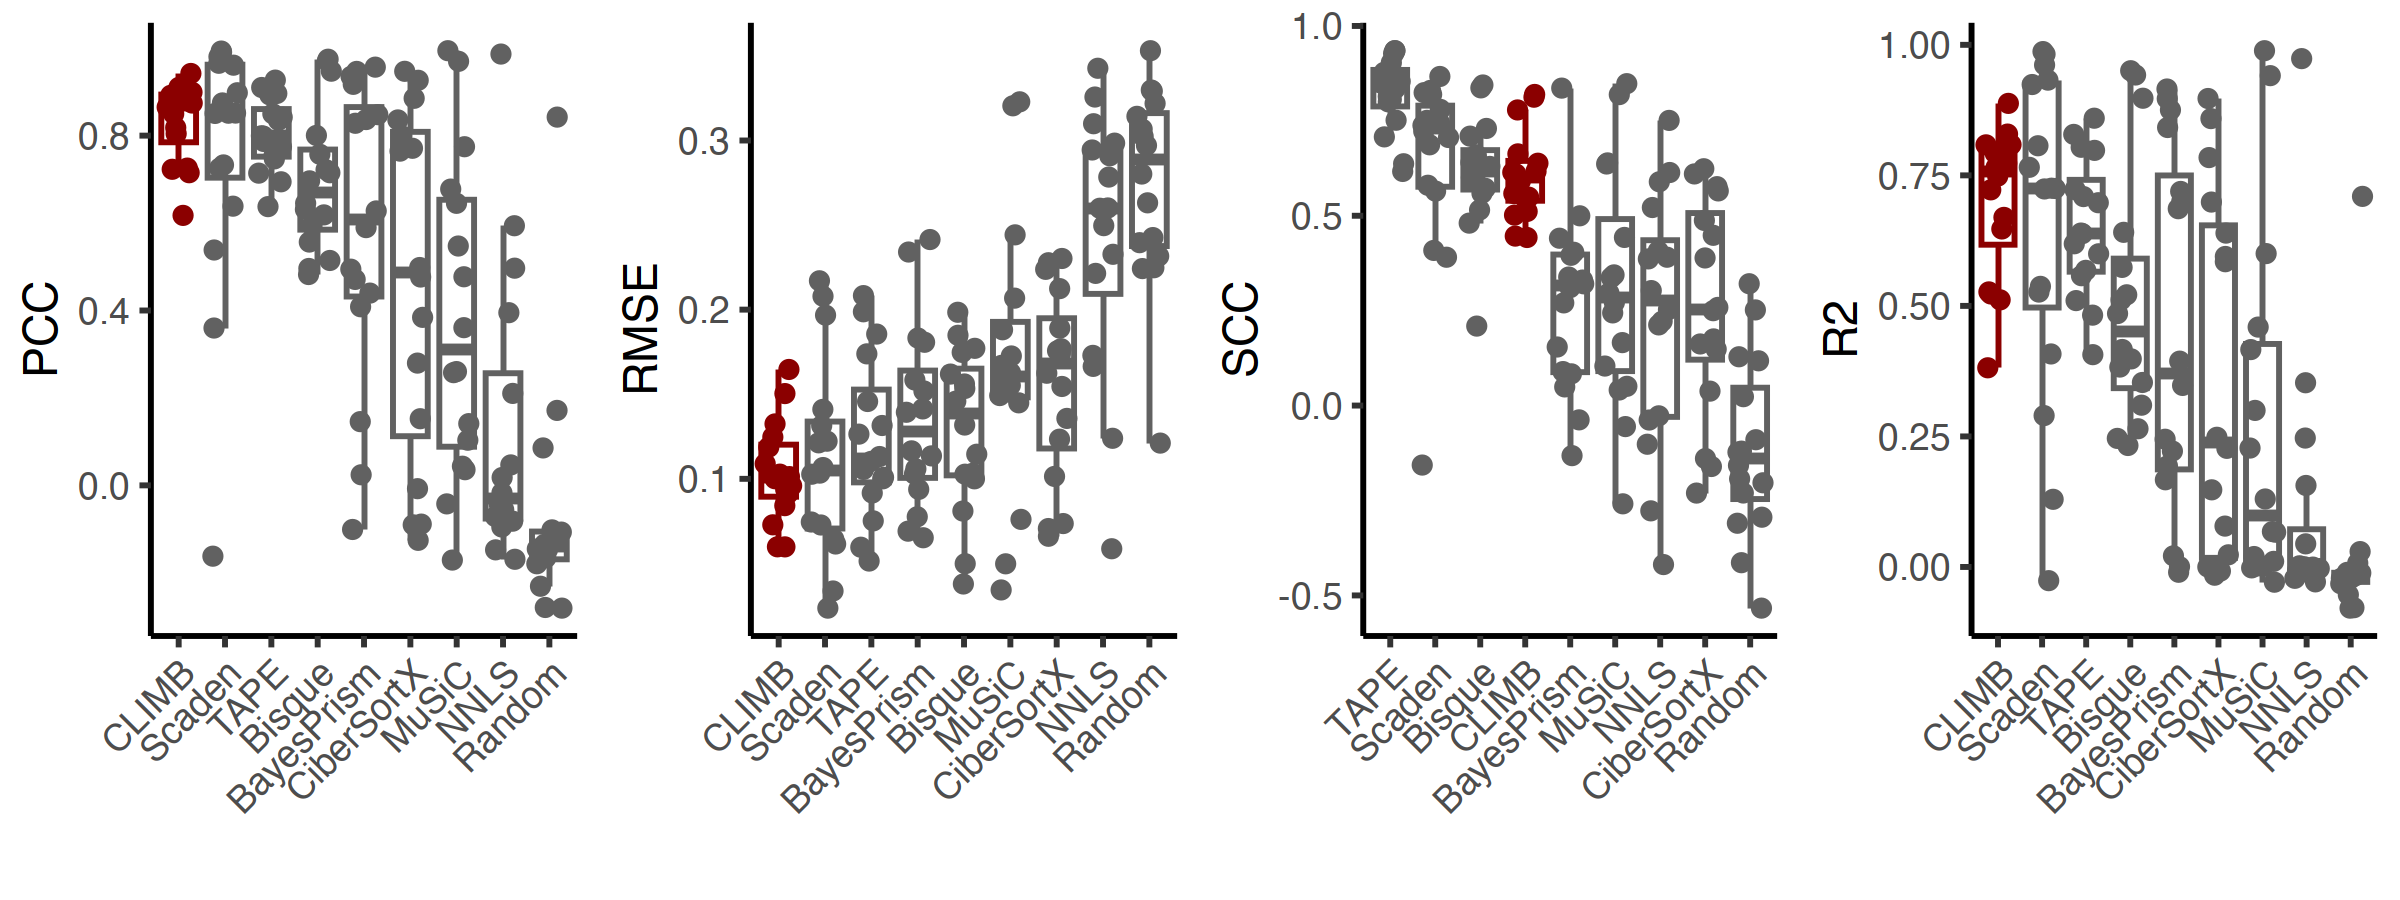

In [25]:
### Naldini > Van Galen analysis
g_pcc = generate_comp_plot(aml.na2vg, type.err='PCC_per_sample') # PCC
g_scc = generate_comp_plot(aml.na2vg, type.err='SCC_per_sample') # SCC
g_r2 = generate_comp_plot(aml.na2vg, type.err='R2_per_sample') # R-square
g_rmse = generate_comp_plot(aml.na2vg, type.err='RMSE_per_sample') # RMSE
options(repr.plot.width=8, repr.plot.height=3, repr.plot.res=300)
ggarrange(g_pcc, g_rmse, g_scc, g_r2, ncol=4, nrow=1)

No id variables; using all as measure variables

No id variables; using all as measure variables

No id variables; using all as measure variables

No id variables; using all as measure variables



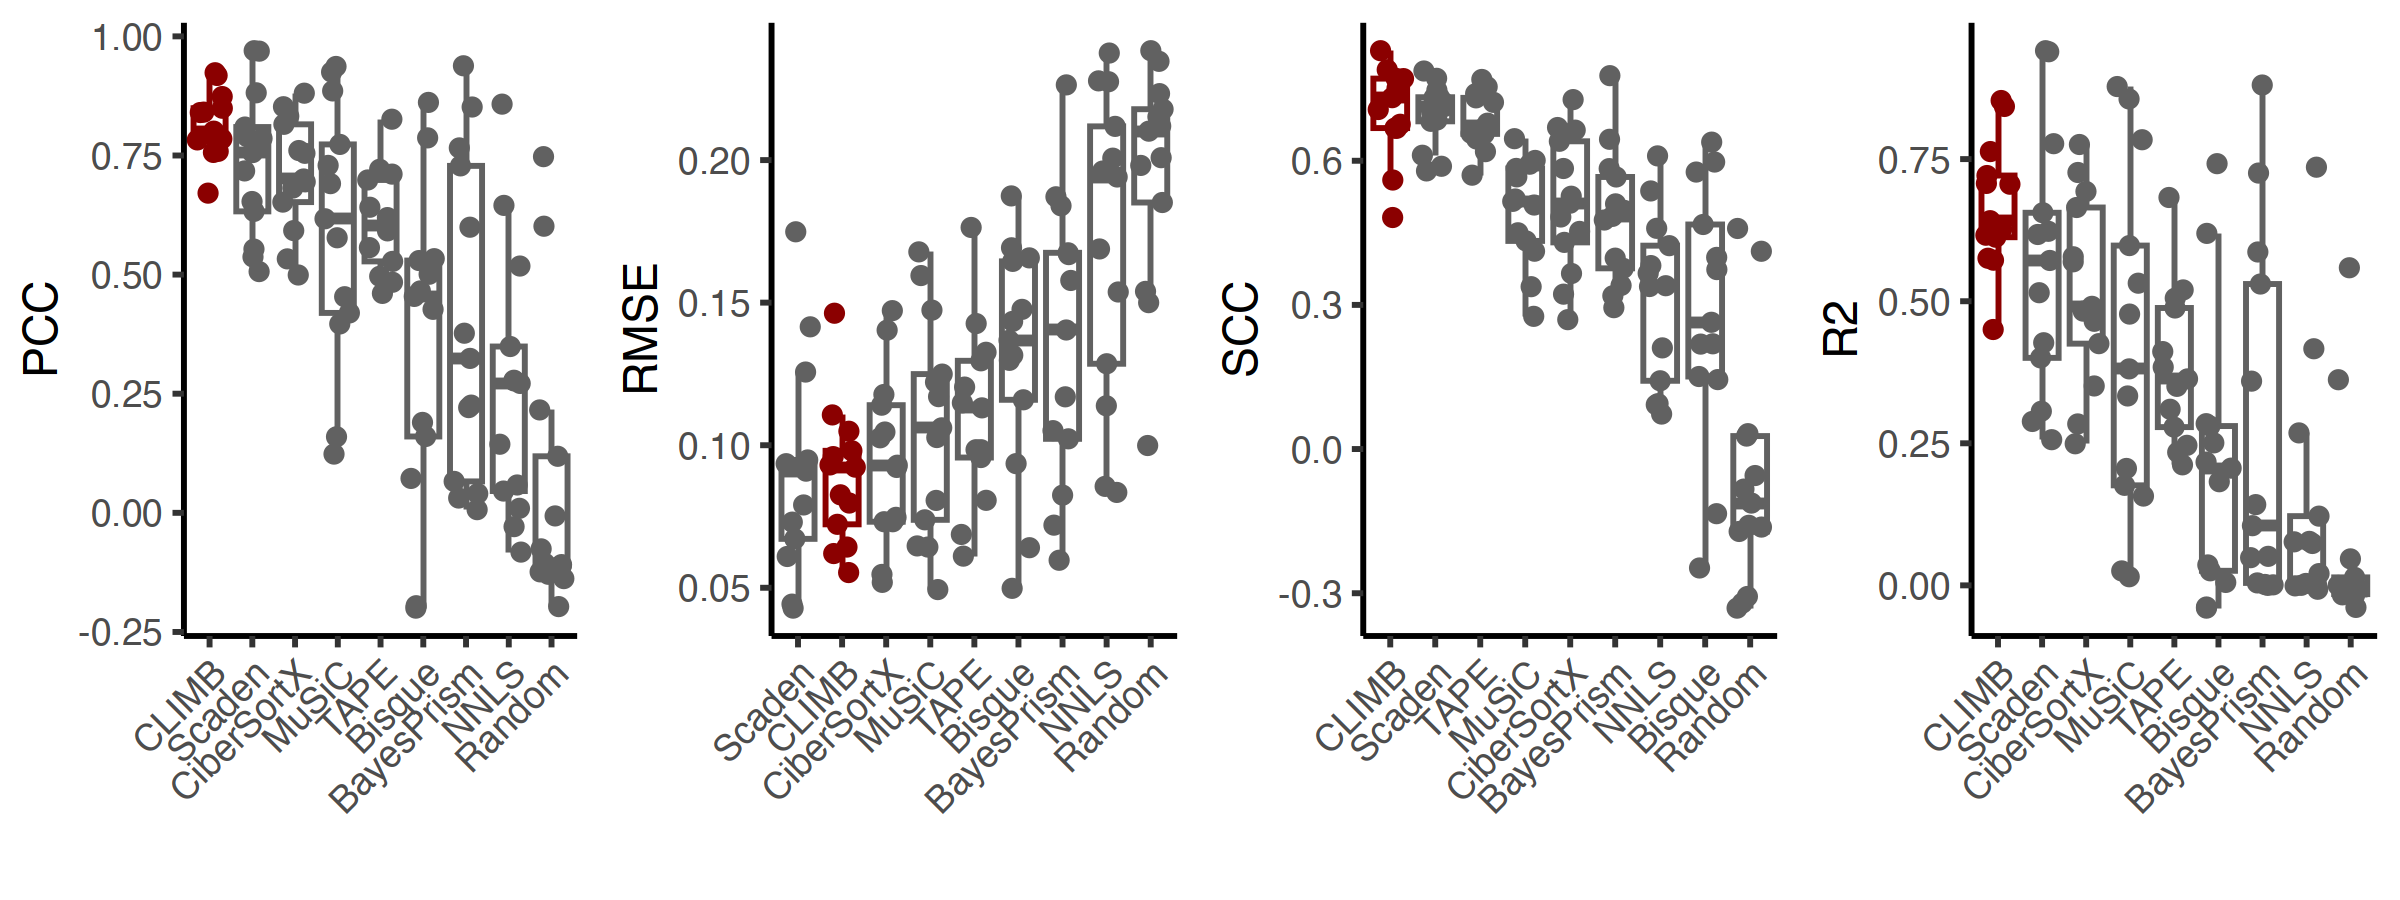

In [26]:
### Van Galen > Naldini 
g_pcc = generate_comp_plot(aml.vg2na, type.err='PCC_per_sample') # PCC
g_scc = generate_comp_plot(aml.vg2na, type.err='SCC_per_sample') # SCC
g_r2 = generate_comp_plot(aml.vg2na, type.err='R2_per_sample') # R-square
g_rmse = generate_comp_plot(aml.vg2na, type.err='RMSE_per_sample') # RMSE
ggarrange(g_pcc, g_rmse, g_scc, g_r2, ncol=4, nrow=1)

No id variables; using all as measure variables

No id variables; using all as measure variables

No id variables; using all as measure variables

No id variables; using all as measure variables



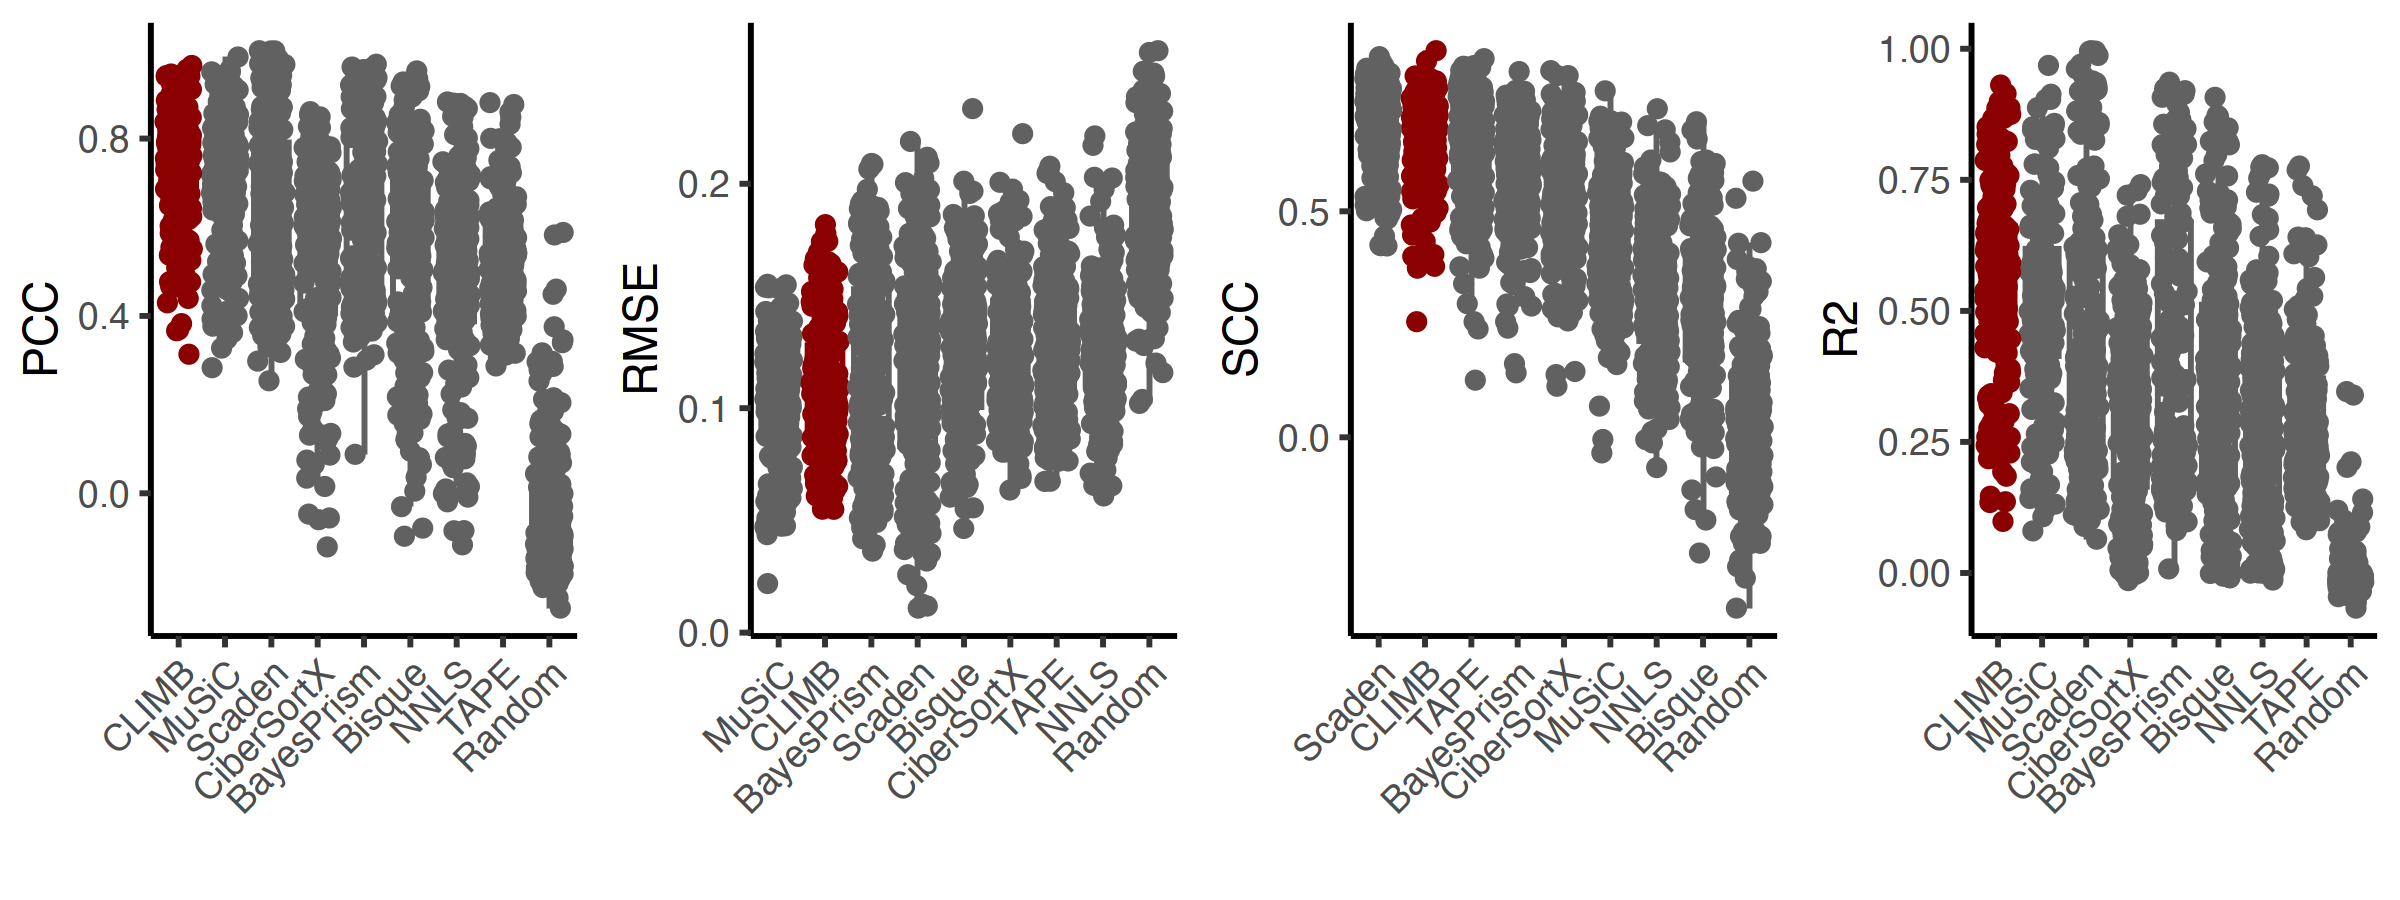

In [27]:
### 200 Simulated bulks
g_pcc = generate_comp_plot(aml.vg2na_200sim, type.err='PCC_per_sample') # PCC
g_scc = generate_comp_plot(aml.vg2na_200sim, type.err='SCC_per_sample') # SCC
g_r2 = generate_comp_plot(aml.vg2na_200sim, type.err='R2_per_sample') # R-square
g_rmse = generate_comp_plot(aml.vg2na_200sim, type.err='RMSE_per_sample') # RMSE
ggarrange(g_pcc, g_rmse, g_scc, g_r2, ncol=4, nrow=1)

### Assembling results from multiple analysis

Now we assemble the results from the 4 AML analysis and make a single figure. The idea is to use ranks provided by each metric (PCC, SCC, RMSE, and R2), and assemble all rankings of multiple analysis and multiple metrics in a single figure.

In [31]:
# Compute Rankings with all four metrics per sample
ranks.vg2na = rank_all_metrics(aml.vg2na)
ranks.na2vg = rank_all_metrics(aml.na2vg)
ranks.vg2na_200sim = rank_all_metrics(aml.vg2na_200sim)
ranks.invitro = rank_all_metrics(invitro)

In [32]:
# Assemble rankings obtained in different analysis and compute averages
df_all = cbind(ranks.vg2na, ranks.na2vg, ranks.vg2na_200sim, ranks.invitro)
df_all$mean_overall = rowMeans(as.matrix(df_all)) ; df_all$std_overall = rowSds(as.matrix(df_all))
df_all$mean_vg2na = rowMeans(as.matrix(ranks.vg2na))
df_all$mean_na2vg = rowMeans(as.matrix(ranks.na2vg))
df_all$mean_200sim = rowMeans(as.matrix(ranks.vg2na_200sim))
df_all$mean_invitro = rowMeans(as.matrix(ranks.invitro))
df_all$method = rownames(df_all)
df_all$method = factor(df_all$method, levels=rev(df_all$method[order(df_all$mean_overall)]))
df_all = df_all[,17:dim(df_all)[2]]

In [33]:
df_all

,mean_overall,std_overall,mean_vg2na,mean_na2vg,mean_200sim,mean_invitro,method
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>
CLIMB,1.40625,0.7749748,1.25,1.75,1.50,1.125,CLIMB
Scaden,2.09375,0.7119241,1.75,2.00,2.75,1.875,Scaden
TAPE,4.87500,1.9645292,4.50,2.50,6.50,6.000,TAPE
CiberSortX,4.87500,1.4523688,3.50,6.75,4.75,4.500,CiberSortX
BayesPrism,4.75000,1.3919411,6.75,4.75,4.25,3.250,BayesPrism
MuSiC,4.37500,1.6909687,4.00,6.50,2.75,4.250,MuSiC
NNLS,7.81250,0.6343057,7.75,7.75,7.25,8.500,NNLS
BisqueRNA,5.93750,1.3905372,6.50,4.00,6.25,7.000,BisqueRNA
Random,8.87500,0.3307189,9.00,9.00,9.00,8.500,Random


`mean_overall` and `std_overall` represent the average and standard deviation of rankings across all studies and all four metrics combined. `mean_vg2na` indicates the mean ranking across four metrics in the 'Van Galen > Naldini' analysis, while `mean_na2vg` signifies the mean ranking in the 'Naldini > Van Galen' analysis. `mean_200sim` represents the mean ranking derived from the analysis of 200 simulated bulk samples, and `mean_invitro` denotes the mean ranking derived from the in-vitro analysis.

In the next figure, `mean_overall` and `std_overall` were used to compute the error bar (black) around the global average (black dot). Then, in-vitro is shown in pink, the 200 simulated bulks in salmon, Naldini > Van Galen in red and Van Galen > Naldini in darkred. 

Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”


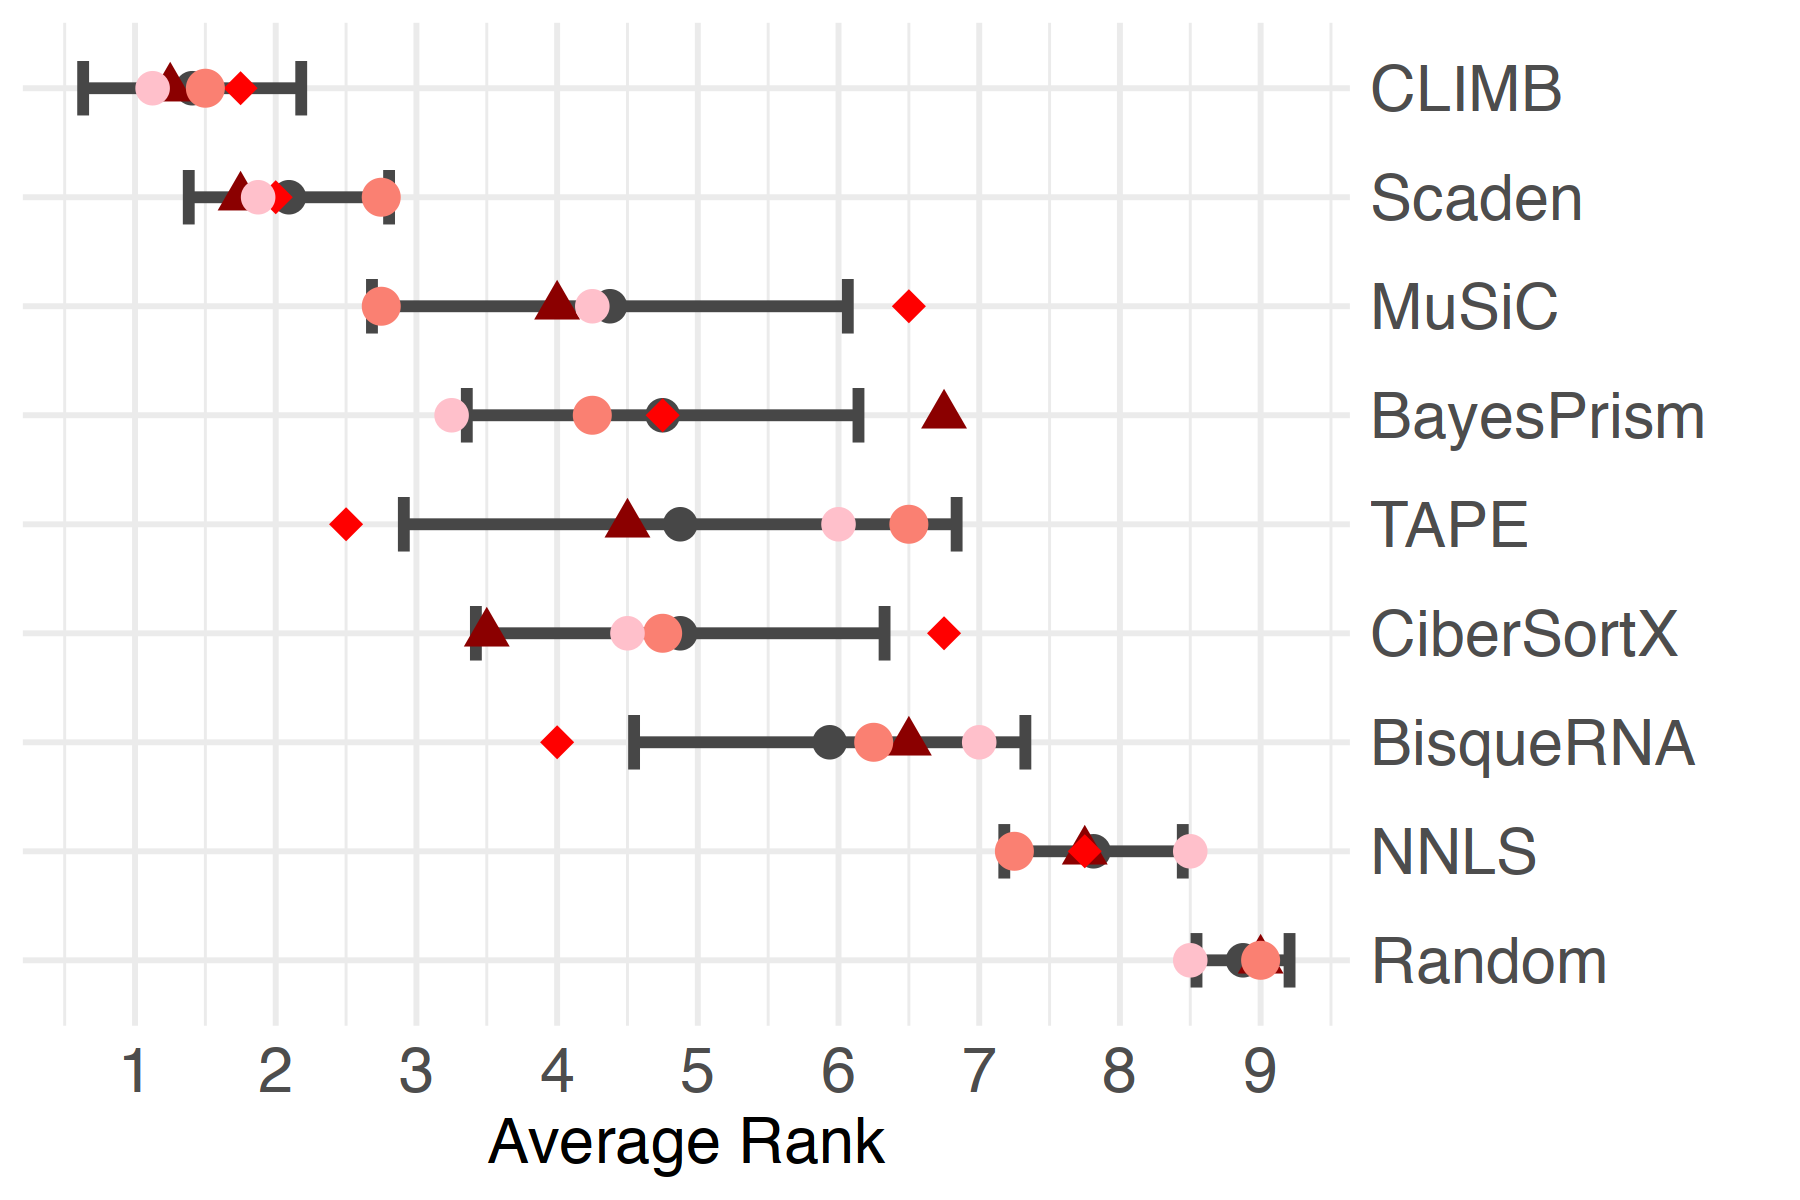

In [34]:
options(repr.plot.width=6, repr.plot.height=4)
ggplot() + geom_errorbar(data=df_all, aes(y=method, xmin=mean_overall-std_overall, xmax=mean_overall+std_overall), width=0.5, size=1, color="grey28") +
    geom_point(data=df_all, aes(x=mean_overall, y=method), size=3.0, color='grey28') + 
    geom_point(data=df_all, aes(x=mean_vg2na, y=method), size=3.5, color='darkred', shape=17) +
    geom_point(data=df_all, aes(x=mean_na2vg, y=method), size=3.5, color='red', shape=18) +
    geom_point(data=df_all, aes(x=mean_200sim, y=method), size=3.5, color='salmon') +
    geom_point(data=df_all, aes(x=mean_invitro, y=method), size=3.0, color='pink') +
    scale_x_continuous(breaks=1:9) + 
    theme_minimal() + theme(axis.text=element_text(size = 15), text=element_text(size = 15)) + xlab('Average Rank') +
    ylab('') + scale_y_discrete(position = "right")

We then compute statistics comparing CLIMB versus other methods ranks with a wilcoxon test, taking all rankings from different analysis and different metrics into account.

In [35]:
print_ranks <- function(rank_matrix){
    print(paste0(rownames(rank_matrix[2,]), ' p-value: ',
        suppressWarnings(wilcox.test(num(rank_matrix[1,]), num(rank_matrix[2,]))$p.value)))
    print(paste0(rownames(rank_matrix[3,]), ' p-value: ',
        suppressWarnings(wilcox.test(num(rank_matrix[1,]), num(rank_matrix[3,]))$p.value)))
    print(paste0(rownames(rank_matrix[4,]), ' p-value: ',
        suppressWarnings(wilcox.test(num(rank_matrix[1,]), num(rank_matrix[4,]))$p.value)))
    print(paste0(rownames(rank_matrix[5,]), ' p-value: ',
        suppressWarnings(wilcox.test(num(rank_matrix[1,]), num(rank_matrix[5,]))$p.value)))
    print(paste0(rownames(rank_matrix[6,]), ' p-value: ',
        suppressWarnings(wilcox.test(num(rank_matrix[1,]), num(rank_matrix[6,]))$p.value)))
    print(paste0(rownames(rank_matrix[7,]), ' p-value: ',
        suppressWarnings(wilcox.test(num(rank_matrix[1,]), num(rank_matrix[7,]))$p.value)))
    print(paste0(rownames(rank_matrix[8,]), ' p-value: ',
        suppressWarnings(wilcox.test(num(rank_matrix[1,]), num(rank_matrix[8,]))$p.value)))
}
aml.ranks = cbind(ranks.vg2na, ranks.na2vg, ranks.vg2na_200sim)
print_ranks(aml.ranks)

[1] "Scaden p-value: 0.026709209315018"
[1] "TAPE p-value: 0.000478485045757691"
[1] "CiberSortX p-value: 6.73078999081735e-05"
[1] "BayesPrism p-value: 3.82561038165779e-05"
[1] "MuSiC p-value: 0.00070988230356411"
[1] "NNLS p-value: 1.83895034909136e-05"
[1] "BisqueRNA p-value: 3.85700004977305e-05"


## Analysis of cellular proportions in AML

We will make now a few additional figures, taking Van Galen > Naldini and Naldini > Van Galen analysis. 

In [30]:
# Van Galen > Naldini analysis: Load true and deconvoluted proprotions
all_props.vg2na = load_all_props('data/pseudobulks_climb/AML_vg2na', include_cibersortx = T)
true_prop.vg2na = read.csv('data/pseudobulks_climb/AML_vg2na/true_prop.csv', row.names='X')

# Make a flattened data.frame with reshape2::melt function as requested by ggplot2
melt_dots.vg2na = cbind(melt(all_props.vg2na$CLIMB), melt(as.matrix(true_prop.vg2na)))[,c(1,2,3,6)]
colnames(melt_dots.vg2na) = c('sample', 'celltype', 'climb', 'true')
melt_dots.vg2na$analysis = 'vg2na'

# Do the same with Scaden proportions 
melt_dots.scaden.vg2na = cbind(melt(all_props.vg2na$Scaden), melt(as.matrix(true_prop.vg2na)))[,c(1,2,3,6)]
colnames(melt_dots.scaden.vg2na) = c('sample', 'celltype', 'scaden', 'true')
melt_dots.scaden.vg2na$analysis = 'vg2na'

Checking that all tables have the same cell-type labels: TRUE

Checking that all tables has the same sample names: TRUE



In [31]:
# Do it again for Naldini > Van Galen analysis
all_props.na2vg = load_all_props('data/pseudobulks_climb/AML_na2vg', include_cibersortx = T)
true_prop.na2vg = read.csv('data/pseudobulks_climb/AML_na2vg/true_prop.csv', row.names='X')

# Extract CLIMB and Scaden proportions and make flattened data.frame with reshape2::melt
melt_dots.na2vg = cbind(melt(all_props.na2vg$CLIMB), melt(as.matrix(true_prop.na2vg)))[,c(1,2,3,6)]
colnames(melt_dots.na2vg) = c('sample', 'celltype', 'climb', 'true')
melt_dots.na2vg$analysis = 'na2vg'
melt_dots.scaden.na2vg = cbind(melt(all_props.na2vg$Scaden), melt(as.matrix(true_prop.na2vg)))[,c(1,2,3,6)]
colnames(melt_dots.scaden.na2vg) = c('sample', 'celltype', 'scaden', 'true')
melt_dots.scaden.na2vg$analysis = 'na2vg'

Checking that all tables have the same cell-type labels: TRUE

Checking that all tables has the same sample names: TRUE



In [32]:
# Assemble results from both 'Van Galen > Naldini' and 'Naldini > Van Galen' analysis
melt_dots = rbind(melt_dots.vg2na, melt_dots.na2vg) # CLIMB 
melt_dots.scaden = rbind(melt_dots.scaden.vg2na, melt_dots.scaden.na2vg) # Scaden 

Next we make scatter plot of true versus deconvoluted cell subtype proportions, merging analysis of Van Galen > Naldini and Naldini > Van Galen. We will do it for CLIMB and Scaden methods. 

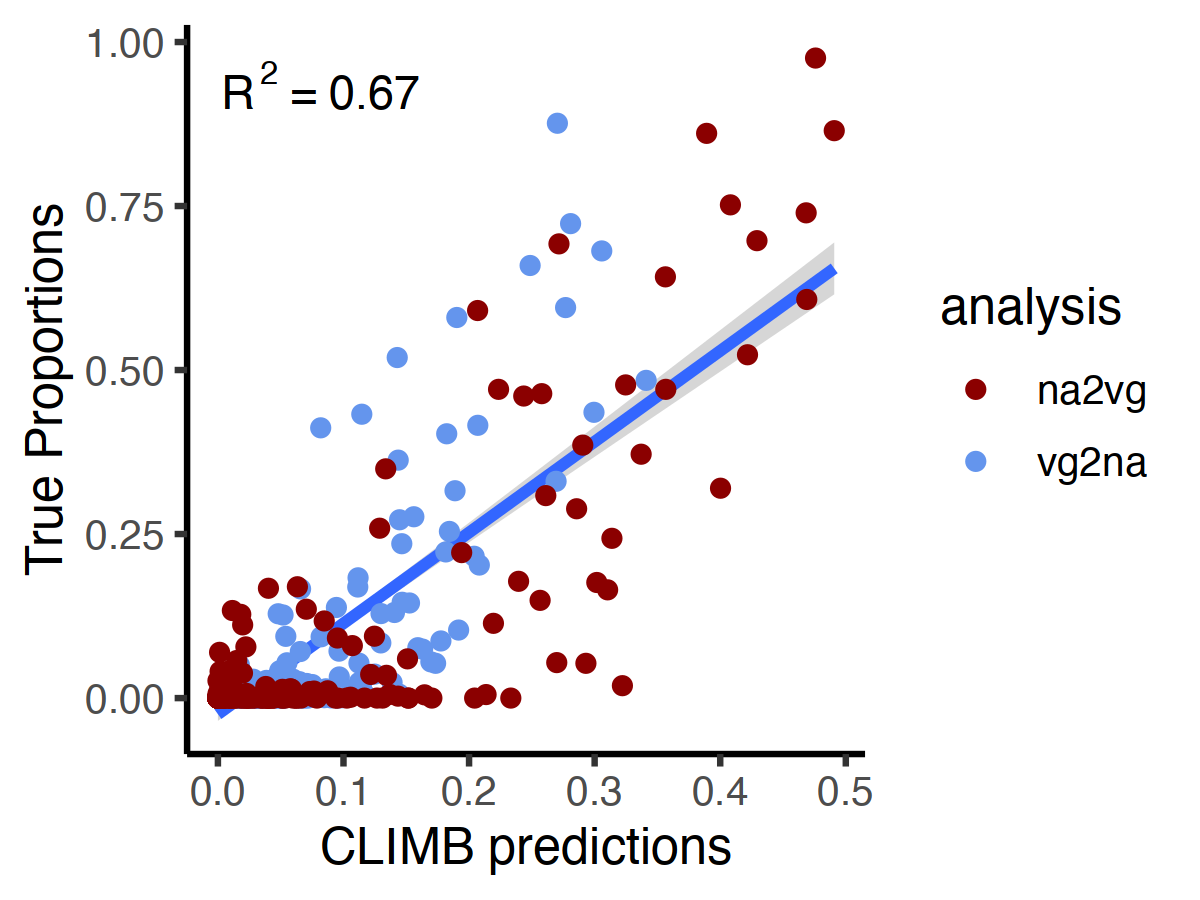

In [34]:
options(repr.plot.width=4, repr.plot.height=3, repr.plot.res=300)
ggplot(data=melt_dots) + 
    scale_color_manual(values=c('darkred', 'cornflowerblue')) + theme_classic2() +
    stat_poly_line(aes(y=true, x=climb)) + stat_poly_eq(aes(y=true, x=climb)) +
    geom_point(aes(x=climb, y=true, color=analysis)) + 
    ylab('True Proportions') + xlab('CLIMB predictions')

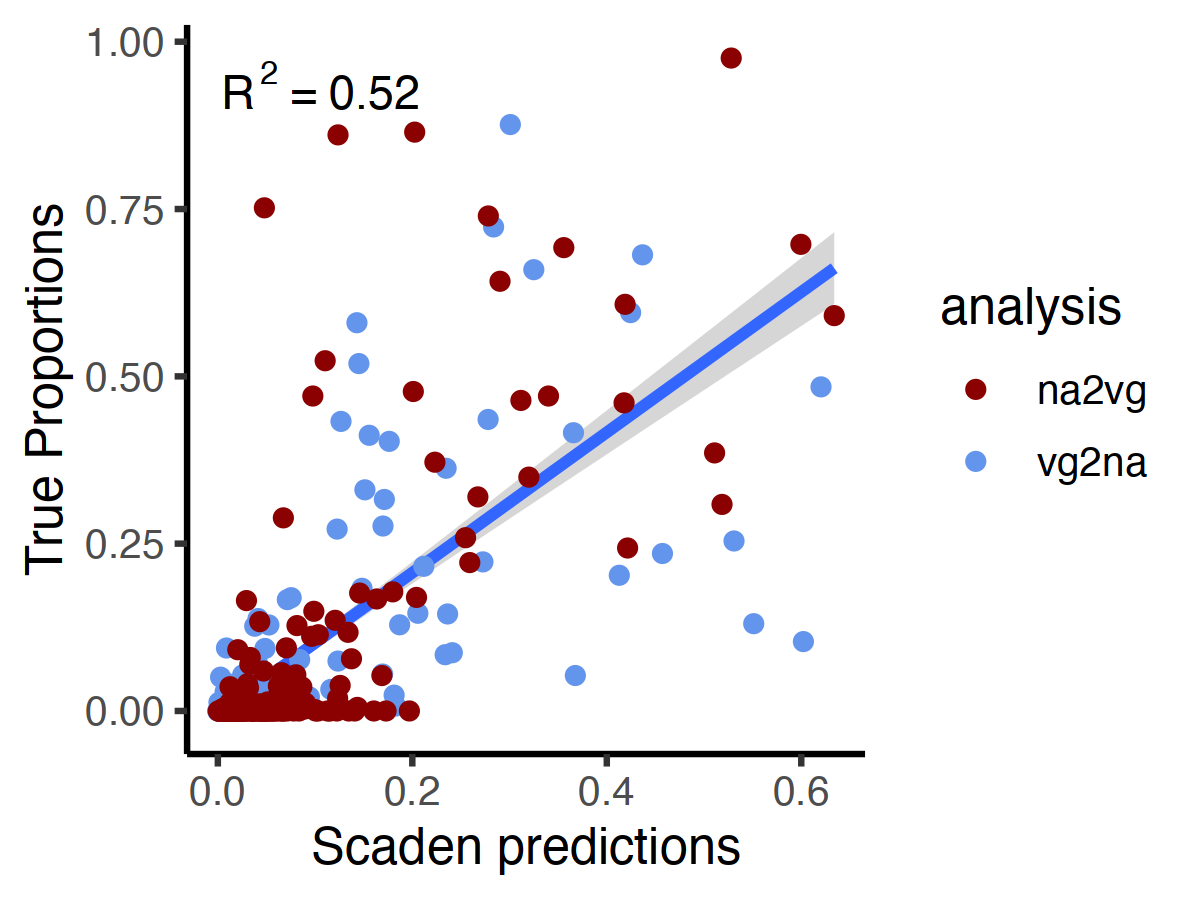

In [35]:
options(repr.plot.width=4, repr.plot.height=3, repr.plot.res=300)
ggplot(data=melt_dots.scaden) + 
    scale_color_manual(values=c('darkred', 'cornflowerblue')) + theme_classic2() +
    stat_poly_line(aes(y=true, x=scaden)) + stat_poly_eq(aes(y=true, x=scaden)) +
    geom_point(aes(x=scaden, y=true, color=analysis)) + 
    ylab('True Proportions') + xlab('Scaden predictions')

## Analysis of HSC-like proportions 

We put an emphasis on HSC-like cell subtype in AML, as this cell subtype probably emcompass the Leukemic Stem Cells, a cell subtype of high clinical interest. In the analysis Van Galen > Naldini, we have deconvoluted proportions of HSC-like in 13 samples, we can thus get correlation metrics for HSC-like.

In [36]:
# Compute accuracy for HSC-like cell-type in Van Galen > Naldini context
all_hsclike_cor = c(cor(all_props.vg2na$CLIMB[,'HSClike'], true_prop.vg2na[,'HSClike']),
                    cor(all_props.vg2na$CiberSortX[,'HSClike'], true_prop.vg2na[,'HSClike']),
                    cor(all_props.vg2na$Scaden[,'HSClike'], true_prop.vg2na[,'HSClike']),
                    cor(all_props.vg2na$TAPE[,'HSClike'], true_prop.vg2na[,'HSClike']),
                    cor(all_props.vg2na$BayesPrism[,'HSClike'], true_prop.vg2na[,'HSClike']),
                    cor(all_props.vg2na$MuSiC[,'HSClike'], true_prop.vg2na[,'HSClike']),
                    cor(all_props.vg2na$NNLS[,'HSClike'], true_prop.vg2na[,'HSClike']),
                    cor(all_props.vg2na$BisqueRNA[,'HSClike'], true_prop.vg2na[,'HSClike']),
                    cor(all_props.vg2na$Random[,'HSClike'], true_prop.vg2na[,'HSClike']))
df_pcc = data.frame(pcc=all_hsclike_cor, method=names(all_props.vg2na)) # we remove CLIMB with no weight
# Reorder factors
df_pcc$method = factor(df_pcc$method, levels=df_pcc$method[order(df_pcc$pcc)])

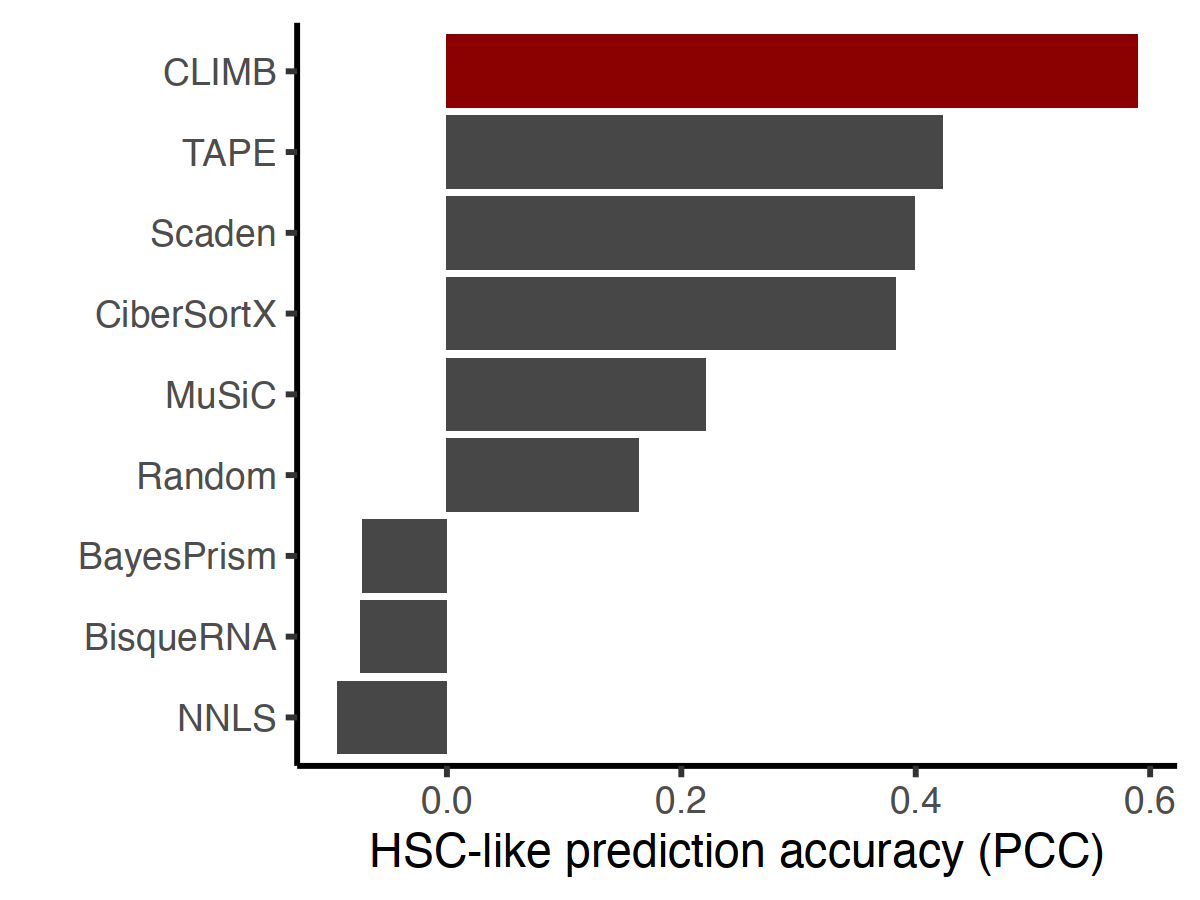

In [37]:
options(repr.plot.width=4, repr.plot.height=3, repr.plot.res=300)
ggplot(df_pcc) + geom_bar(aes(y=method, x=pcc, fill=method), stat="identity") + theme_classic() + 
    xlab('HSC-like prediction accuracy (PCC)') + ylab('') +
    scale_fill_manual(values = ifelse(grepl('CLIMB', levels(df_pcc$method)), 'darkred', 'grey28'), guide="none")

This analysis can unfortunately not be done in the Naldini > Van Galen context as we use Naldini's cell-type. Naldini's cell-type does not distinguish cancer from normal cells (Van Galen used single-cell DNA-seq to distinguish them). Naldini contains CD34+ HSC cells (normal), but zero of these cells were transfered to Van Galen by Seurat's integration.

# CRC - color-rectal cancer cross-dataset analysis

We know perform the cross-dataset deconvolution analysis for two colorectal cancer dataset: Lee et al. and Khaliq et al.. 
- Lee > Khaliq (CRC): Cross-dataset pseudo-bulk analysis where the scRNA-seq dataset from Lee was used as a reference to deconvolute the pseudo-bulks made from Khaliq dataset, after data integration and transfering of cell subtype labels from Lee to Khaliq. 
- Khaliq > Lee (CRC): Cross-dataset pseudo-bulk analysis where the scRNA-seq dataset from Khaliq was used as a reference to deconvolute the pseudo-bulks made from Lee dataset, after data integration and transfering of cell subtype labels from Lee to Khaliq (labels from Lee were used here as we did not find good labels for Khaliq dataset).

In [38]:
# Load props and compute all metrics
out_dir = 'data/pseudobulks_climb/CRC_kha2lee'
crc.kha2lee = make_all_metrics(load_all_props(out_dir, include_cibersortx = T), paste0(out_dir, '/true_prop.csv'))
out_dir = 'data/pseudobulks_climb/CRC_lee2kha'
crc.lee2kha = make_all_metrics(load_all_props(out_dir, include_cibersortx = T), paste0(out_dir, '/true_prop.csv'))
# Compute rank over 4 metrics
ranks.kha2lee = rank_all_metrics(crc.kha2lee)
ranks.lee2kha = rank_all_metrics(crc.lee2kha)

Checking that all tables have the same cell-type labels: FALSE

Checking that all tables has the same sample names: TRUE

Checking that all tables have the same cell-type labels: FALSE

Checking that all tables has the same sample names: TRUE



No id variables; using all as measure variables

No id variables; using all as measure variables

No id variables; using all as measure variables

No id variables; using all as measure variables



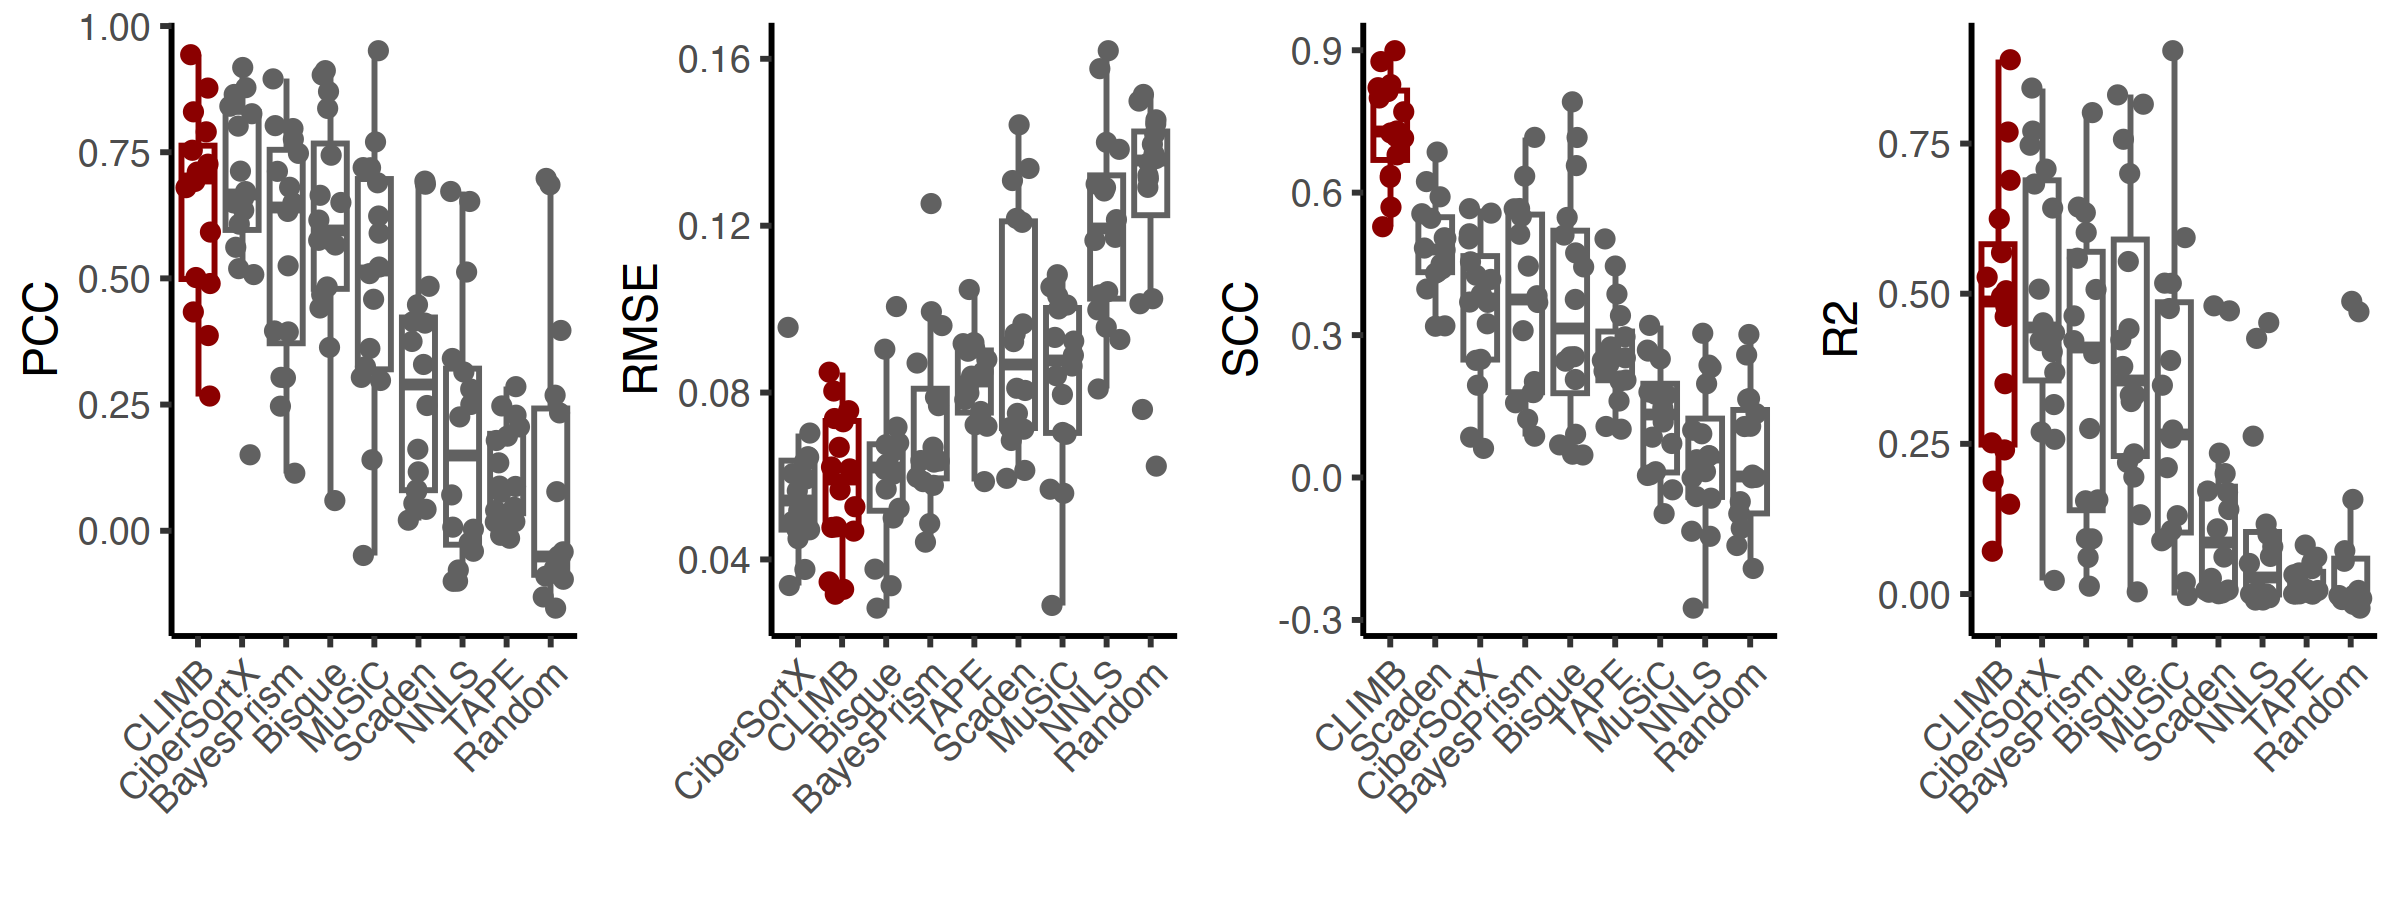

In [39]:
# Make figure for Lee > Khaliq analysis 
g_pcc = generate_comp_plot(crc.lee2kha, type.err='PCC_per_sample') # PCC
g_scc = generate_comp_plot(crc.lee2kha, type.err='SCC_per_sample') # SCC
g_r2 = generate_comp_plot(crc.lee2kha, type.err='R2_per_sample') # R-square
g_rmse = generate_comp_plot(crc.lee2kha, type.err='RMSE_per_sample') # RMSE
options(repr.plot.width=8, repr.plot.height=3)
ggarrange(g_pcc, g_rmse, g_scc, g_r2, ncol=4, nrow=1)

No id variables; using all as measure variables

No id variables; using all as measure variables

No id variables; using all as measure variables

No id variables; using all as measure variables



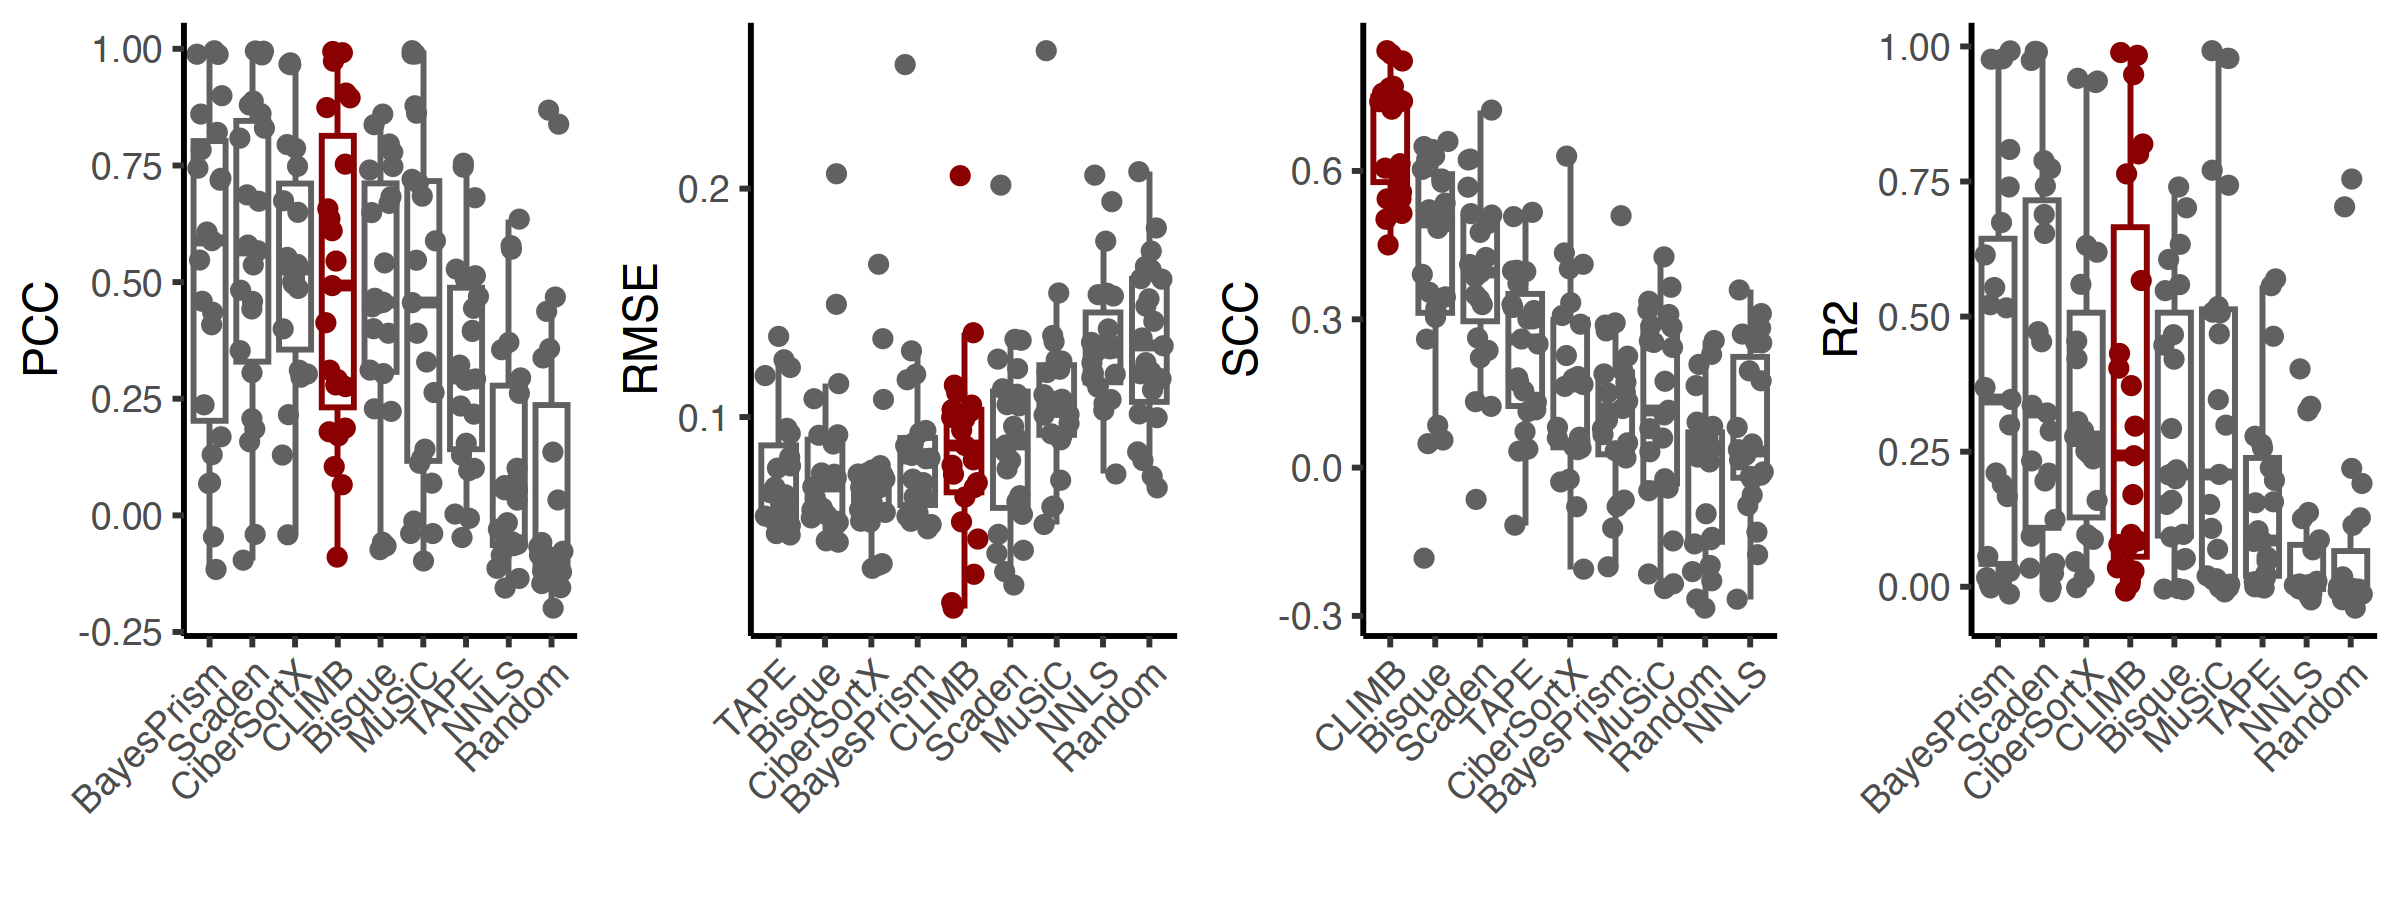

In [40]:
# Same for Khaliq > Lee analysis 
g_pcc = generate_comp_plot(crc.kha2lee, type.err='PCC_per_sample') # PCC
g_scc = generate_comp_plot(crc.kha2lee, type.err='SCC_per_sample') # SCC
g_r2 = generate_comp_plot(crc.kha2lee, type.err='R2_per_sample') # R-square
g_rmse = generate_comp_plot(crc.kha2lee, type.err='RMSE_per_sample') # RMSE
options(repr.plot.width=8, repr.plot.height=3)
ggarrange(g_pcc, g_rmse, g_scc, g_r2, ncol=4, nrow=1)

### Ranking analysis

We then combine all ranking from CRC context to make a single figure:

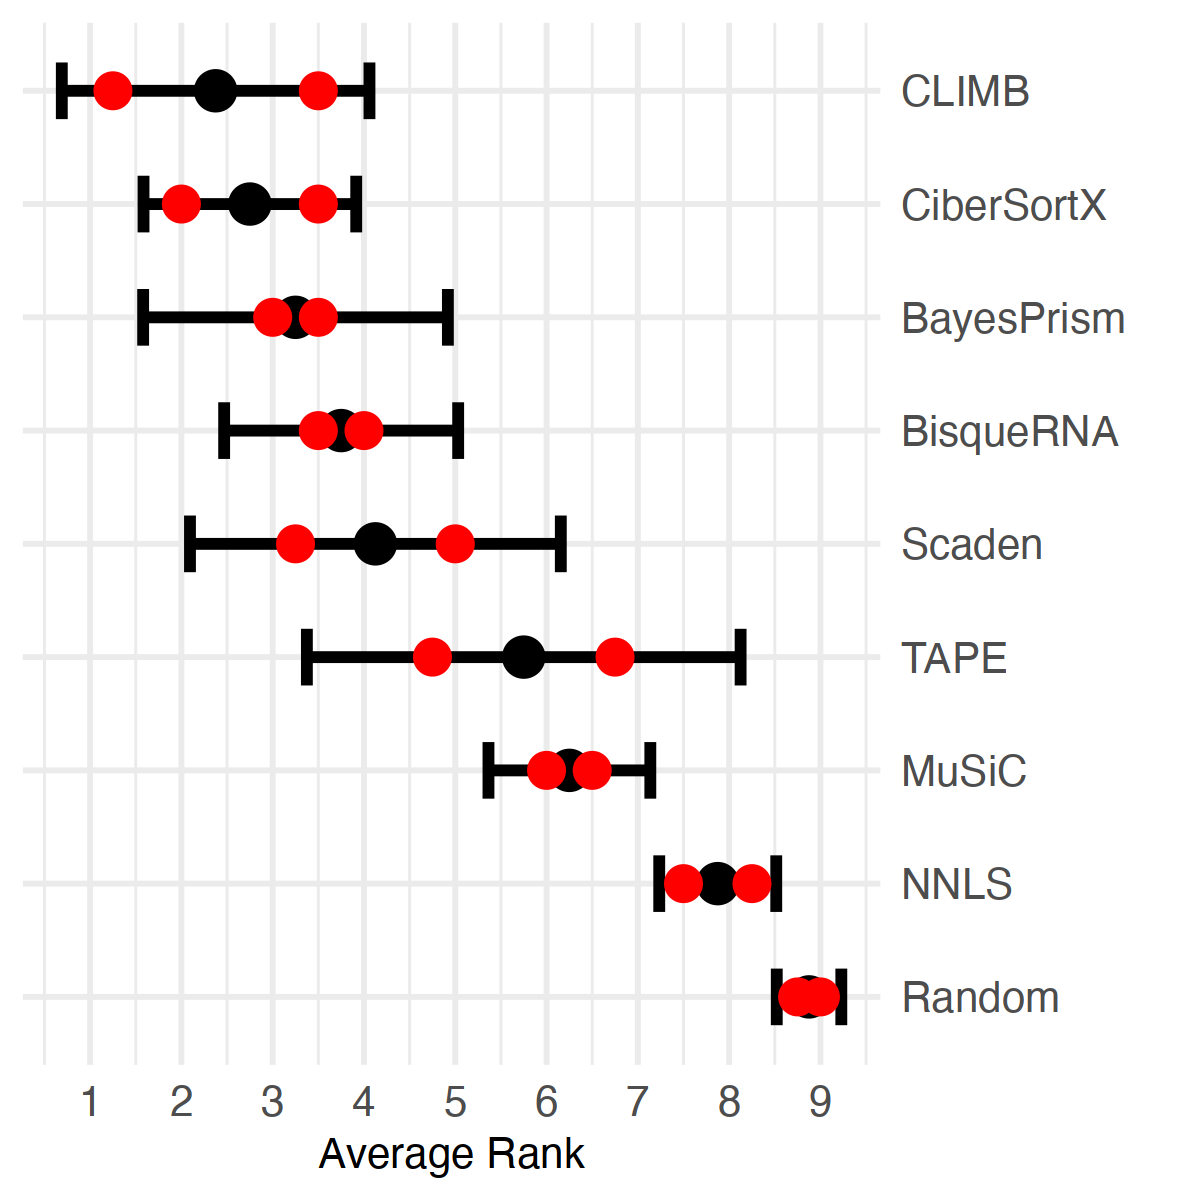

In [41]:
df_all.crc = cbind(ranks.kha2lee, ranks.lee2kha)
mat_ranks = as.matrix(df_all.crc)
df_all.crc$mean_overall = rowMeans(mat_ranks)
df_all.crc$std_overall = rowSds(mat_ranks)
df_all.crc$mean_inter1 = rowMeans(as.matrix(ranks.kha2lee))
df_all.crc$mean_inter2 = rowMeans(as.matrix(ranks.lee2kha))
df_all.crc$method = rownames(df_all.crc)
df_all.crc$method = factor(df_all.crc$method, levels=rev(df_all.crc$method[order(df_all.crc$mean_overall)]))
df_all.crc = df_all.crc[,(dim(df_all.crc)[2]-10):dim(df_all.crc)[2]]
options(repr.plot.width=4, repr.plot.height=4)
ggplot() + geom_errorbar(data=df_all.crc, aes(y=method, xmin=mean_overall-std_overall, xmax=mean_overall+std_overall), width=0.5, size=1, color="black") +
    geom_point(data=df_all.crc, aes(x=mean_overall, y=method), size=4.0, color='black') + 
    geom_point(data=df_all.crc, aes(x=mean_inter1, y=method), size=3.5, color='red') +
    geom_point(data=df_all.crc, aes(x=mean_inter2, y=method), size=3.5, color='red') +
    scale_x_continuous(breaks=1:9) + 
    theme_minimal() + theme(axis.text=element_text(size = 10), text=element_text(size = 10)) + xlab('Average Rank') +
    ylab('') + scale_y_discrete(position = "right")

# Melanoma cancer

We repeat the same analysis of two cross-dataset deconvolution results in the context of melanoma, with Tirosh et al. and Jerby et al. datasets:
- Jerby > Tirosh (Melanoma): Cross-dataset pseudo-bulk analysis where the scRNA-seq dataset from Jerby was used as a reference to deconvolute the pseudo-bulks made from Tirosh dataset, after data integration and transfering of cell subtype labels from Jerby to Tirosh. 
- Tirosh > Jerby (Melanoma): Cross-dataset pseudo-bulk analysis where the scRNA-seq dataset from Tirosh was used as a reference to deconvolute the pseudo-bulks made from Jerby dataset, after data integration and transfering of cell subtype labels from Tirosh to Jerby.

In [42]:
out_dir = 'data/pseudobulks_climb/MEL_jer2tir/'
mel.jer2tir = make_all_metrics(load_all_props(out_dir, include_cibersortx = T), paste0(out_dir, '/true_prop.csv'))
out_dir = 'data/pseudobulks_climb/MEL_tir2jer/'
mel.tir2jer = make_all_metrics(load_all_props(out_dir, include_cibersortx = T), paste0(out_dir, '/true_prop.csv'))
# Compute rank over 4 metrics
ranks.jer2tir = rank_all_metrics(mel.jer2tir)
ranks.tir2jer = rank_all_metrics(mel.tir2jer)

Checking that all tables have the same cell-type labels: TRUE

Checking that all tables has the same sample names: TRUE

Checking that all tables have the same cell-type labels: TRUE

Checking that all tables has the same sample names: TRUE



No id variables; using all as measure variables

No id variables; using all as measure variables

No id variables; using all as measure variables

No id variables; using all as measure variables



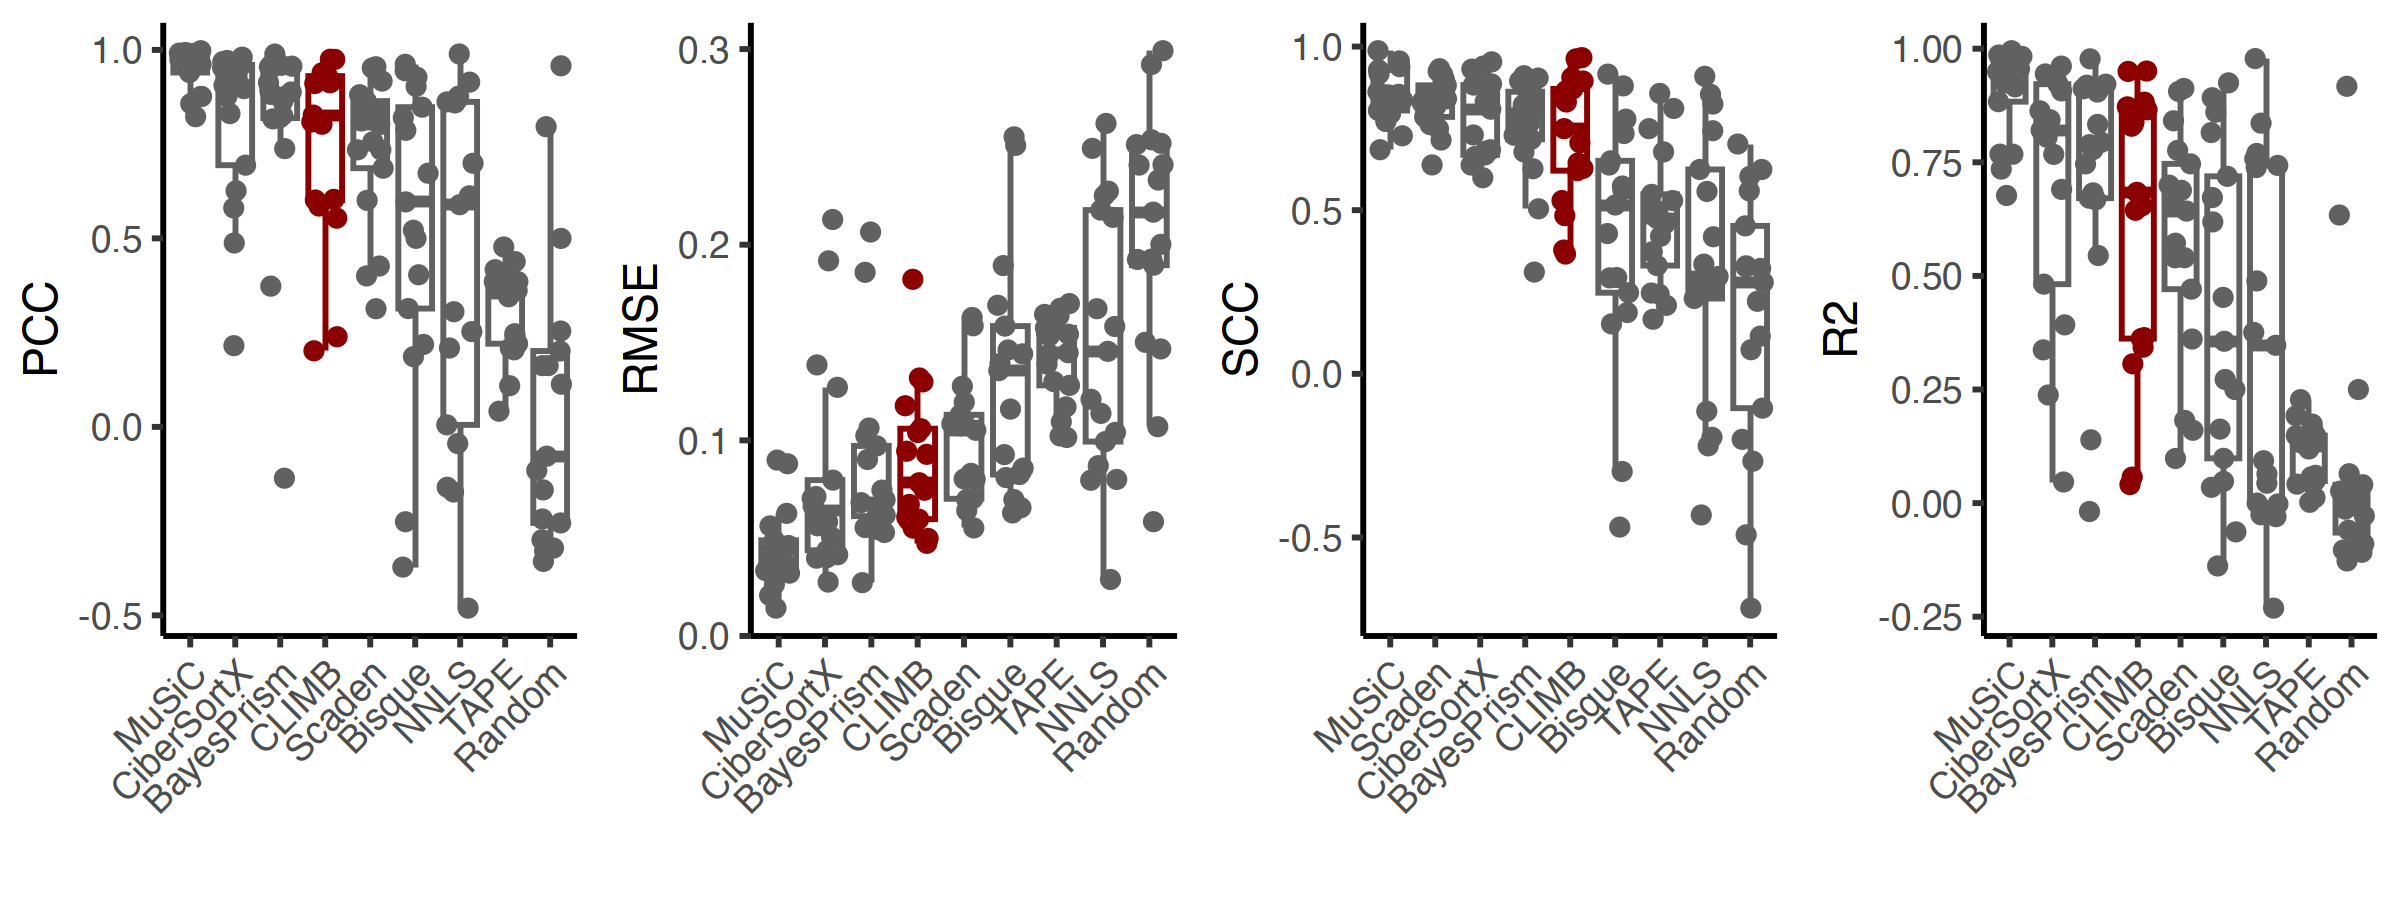

In [43]:
# Tirosh > Jerby analysis
g_pcc = generate_comp_plot(mel.tir2jer, type.err='PCC_per_sample') # PCC
g_scc = generate_comp_plot(mel.tir2jer, type.err='SCC_per_sample') # SCC
g_r2 = generate_comp_plot(mel.tir2jer, type.err='R2_per_sample') # R-square
g_rmse = generate_comp_plot(mel.tir2jer, type.err='RMSE_per_sample') # RMSE
options(repr.plot.width=8, repr.plot.height=3)
ggarrange(g_pcc, g_rmse, g_scc, g_r2, ncol=4, nrow=1)

No id variables; using all as measure variables

No id variables; using all as measure variables

No id variables; using all as measure variables

No id variables; using all as measure variables



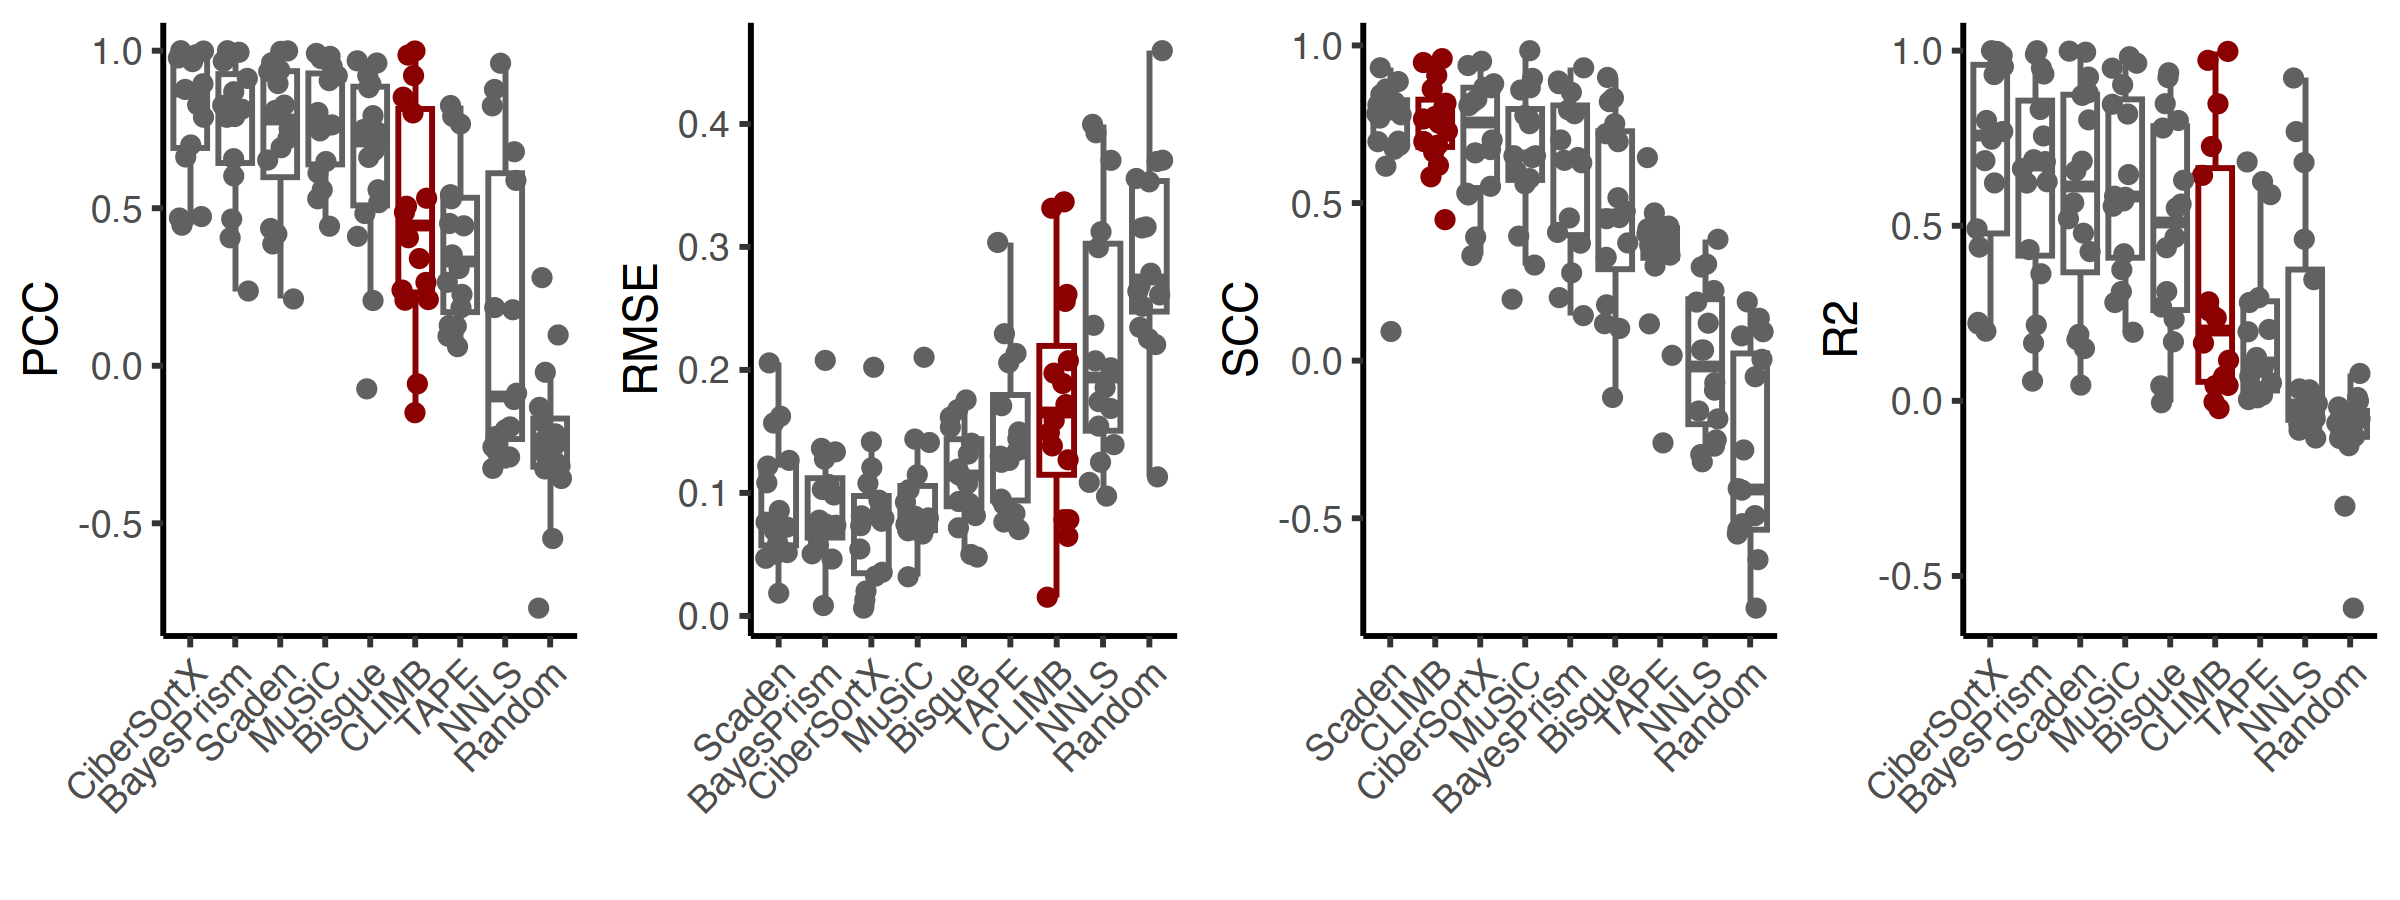

In [44]:
# Jerby > Tirosh analysis
g_pcc = generate_comp_plot(mel.jer2tir, type.err='PCC_per_sample') # PCC
g_scc = generate_comp_plot(mel.jer2tir, type.err='SCC_per_sample') # SCC
g_r2 = generate_comp_plot(mel.jer2tir, type.err='R2_per_sample') # R-square
g_rmse = generate_comp_plot(mel.jer2tir, type.err='RMSE_per_sample') # RMSE
options(repr.plot.width=8, repr.plot.height=3)
ggarrange(g_pcc, g_rmse, g_scc, g_r2, ncol=4, nrow=1)

Assembling rankings from both analysis :

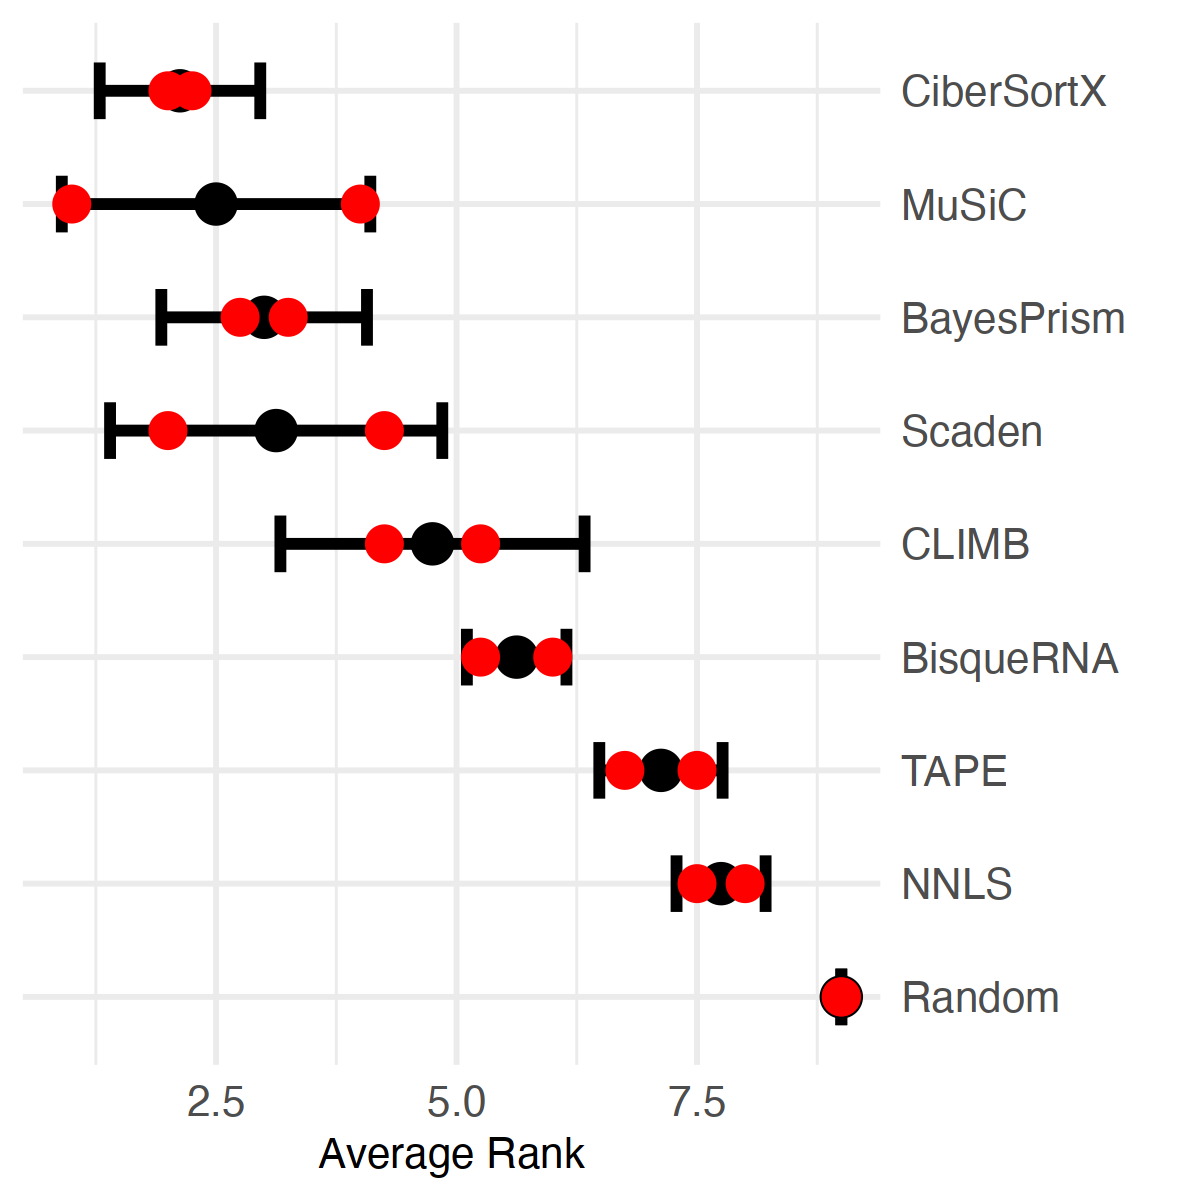

In [45]:
df_all.mel = cbind(ranks.jer2tir, ranks.tir2jer)
mat_ranks = as.matrix(df_all.mel)
df_all.mel$mean_overall = rowMeans(mat_ranks)
df_all.mel$std_overall = rowSds(mat_ranks)
df_all.mel$mean_inter1 = rowMeans(as.matrix(ranks.jer2tir))
df_all.mel$mean_inter2 = rowMeans(as.matrix(ranks.tir2jer))
df_all.mel$method = rownames(df_all.mel)
df_all.mel$method = factor(df_all.mel$method, levels=rev(df_all.mel$method[order(df_all.mel$mean_overall)]))
df_all.mel = df_all.mel[,(dim(df_all.mel)[2]-10):dim(df_all.mel)[2]]
options(repr.plot.width=4, repr.plot.height=4)
ggplot() + geom_errorbar(data=df_all.mel, aes(y=method, xmin=mean_overall-std_overall, xmax=mean_overall+std_overall), width=0.5, size=1, color="black") +
    geom_point(data=df_all.mel, aes(x=mean_overall, y=method), size=4.0, color='black') + 
    geom_point(data=df_all.mel, aes(x=mean_inter1, y=method), size=3.5, color='red') +
    geom_point(data=df_all.mel, aes(x=mean_inter2, y=method), size=3.5, color='red') +
    theme_minimal() + theme(axis.text=element_text(size = 10), text=element_text(size = 10)) + xlab('Average Rank') +
    ylab('') + scale_y_discrete(position = "right")

# Breast cancer 

We repeat similar assembly of two cross-dataset analysis in the context of Breast cancer, using Wu et al. and Gray et al. dataset:
- Wu > Gray (Breast cancer): Cross-dataset pseudo-bulk analysis where the scRNA-seq dataset from Wu was used as a reference to deconvolute the pseudo-bulks made from Gray dataset, after data integration and transfering of cell subtype labels from Wu to Gray. 
- Gray > Wu (Breast cancer): Cross-dataset pseudo-bulk analysis where the scRNA-seq dataset from Gray was used as a reference to deconvolute the pseudo-bulks made from Wu dataset, after data integration and transfering of cell subtype labels from Gray to Wu.

In [46]:
out_dir = 'data/pseudobulks_climb/BREAST_gray2wu/'
breast.gray2wu = make_all_metrics(load_all_props(out_dir, include_cibersortx = T), paste0(out_dir, '/true_prop.csv'))
out_dir = 'data/pseudobulks_climb/BREAST_wu2gray/'
breast.wu2gray = make_all_metrics(load_all_props(out_dir, include_cibersortx = T), paste0(out_dir, '/true_prop.csv'))
ranks.gray2wu = rank_all_metrics(breast.gray2wu)
ranks.wu2gray = rank_all_metrics(breast.wu2gray)

Checking that all tables have the same cell-type labels: TRUE

Checking that all tables has the same sample names: TRUE

Checking that all tables have the same cell-type labels: TRUE

Checking that all tables has the same sample names: TRUE



No id variables; using all as measure variables

No id variables; using all as measure variables

No id variables; using all as measure variables

No id variables; using all as measure variables



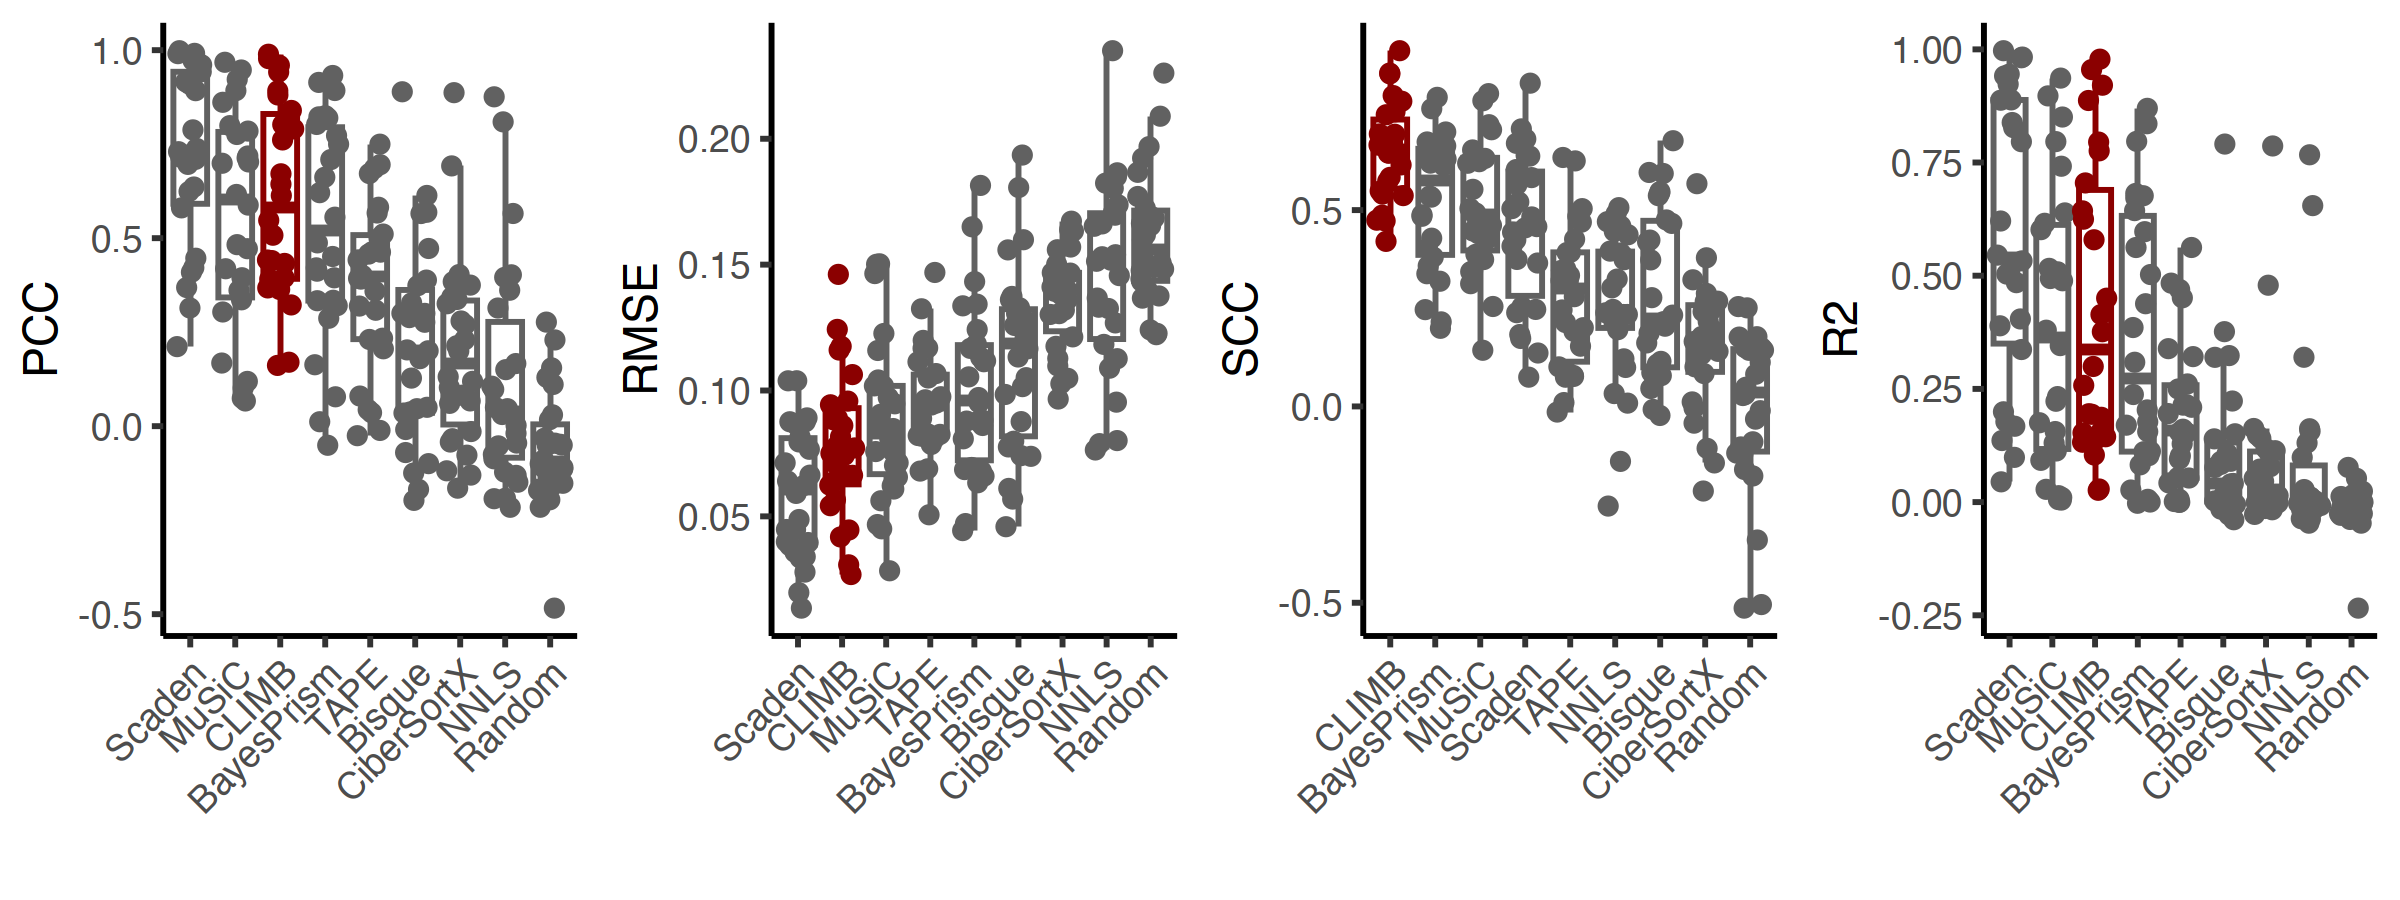

In [47]:
# Gray > Wu analysis
g_pcc = generate_comp_plot(breast.gray2wu, type.err='PCC_per_sample') # PCC
g_scc = generate_comp_plot(breast.gray2wu, type.err='SCC_per_sample') # SCC
g_r2 = generate_comp_plot(breast.gray2wu, type.err='R2_per_sample') # R-square
g_rmse = generate_comp_plot(breast.gray2wu, type.err='RMSE_per_sample') # RMSE
options(repr.plot.width=8, repr.plot.height=3)
ggarrange(g_pcc, g_rmse, g_scc, g_r2, ncol=4, nrow=1)

No id variables; using all as measure variables

No id variables; using all as measure variables

No id variables; using all as measure variables

No id variables; using all as measure variables



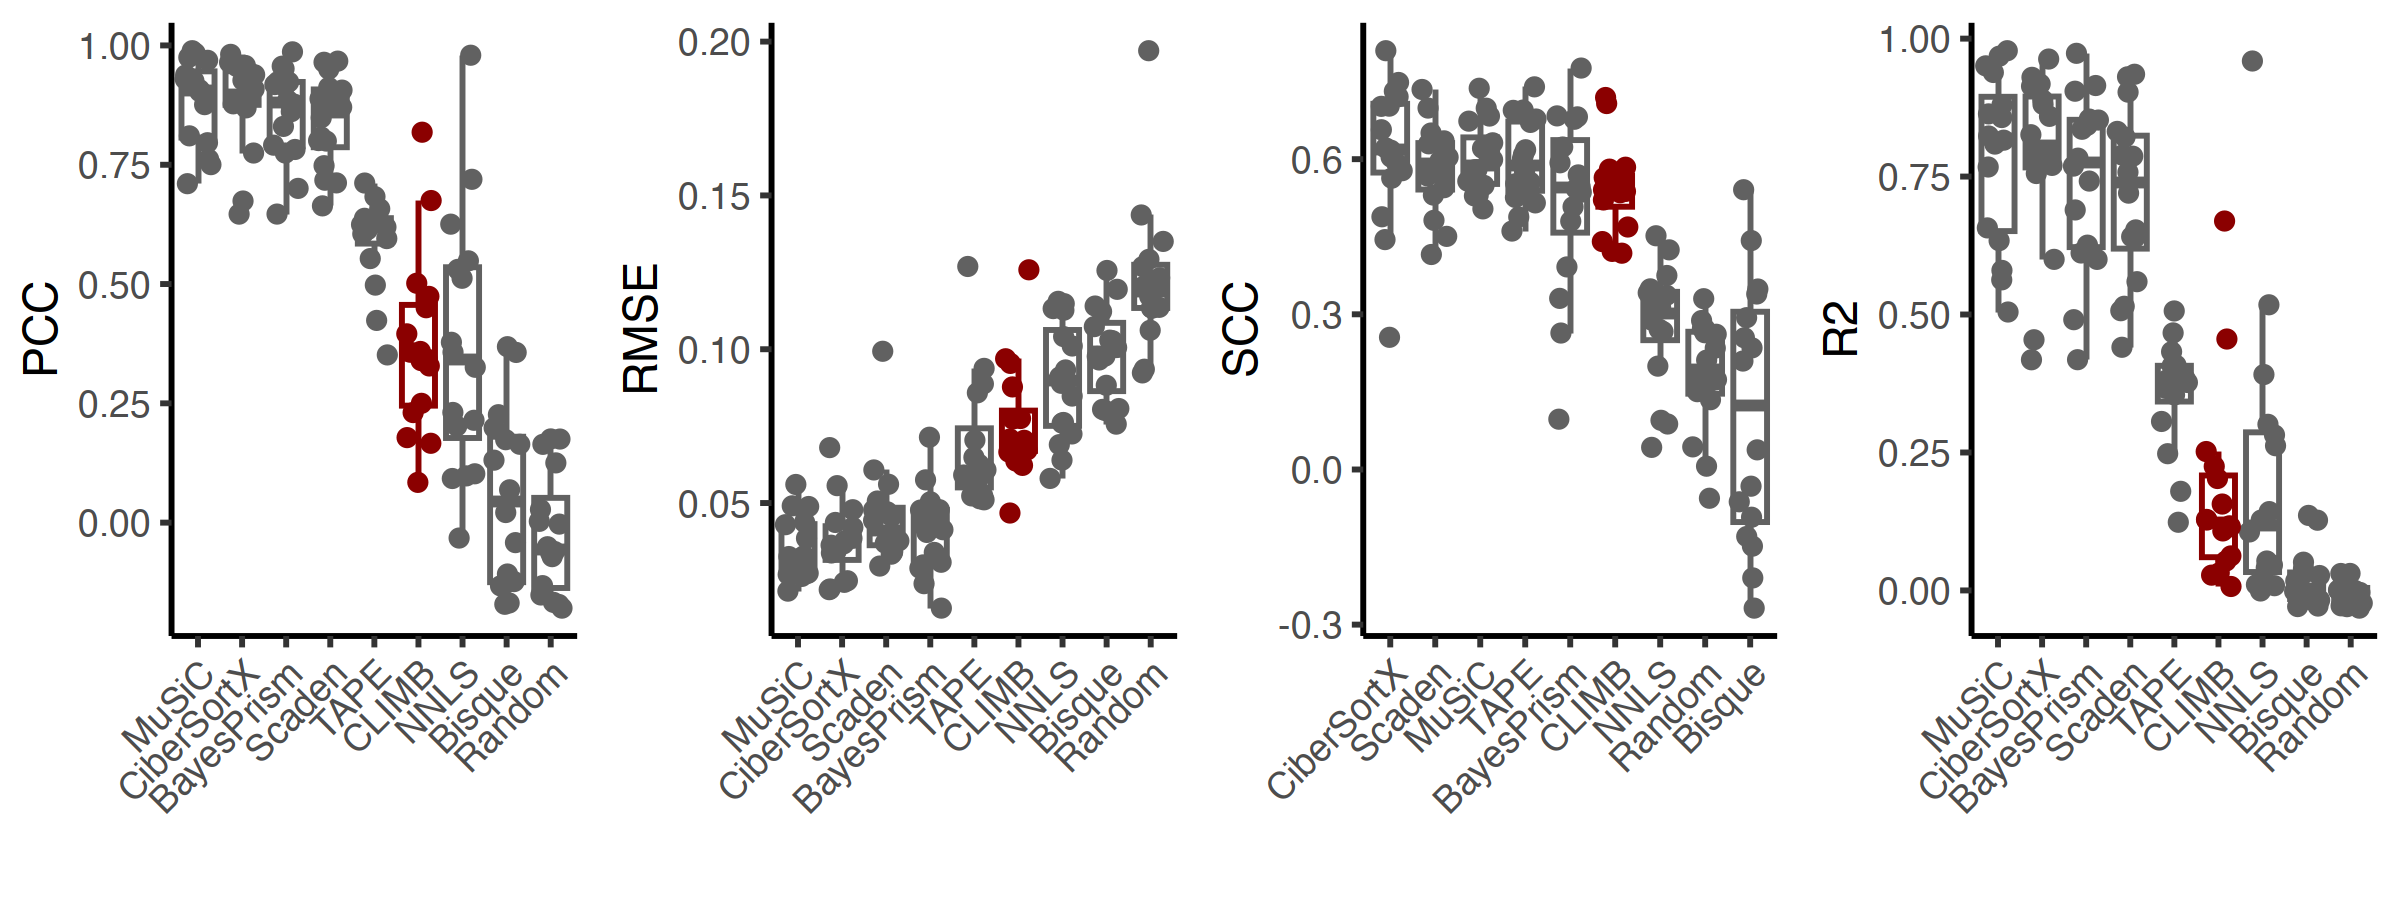

In [48]:
# Wu > Gray analysis
g_pcc = generate_comp_plot(breast.wu2gray, type.err='PCC_per_sample') # PCC
g_scc = generate_comp_plot(breast.wu2gray, type.err='SCC_per_sample') # SCC
g_r2 = generate_comp_plot(breast.wu2gray, type.err='R2_per_sample') # R-square
g_rmse = generate_comp_plot(breast.wu2gray, type.err='RMSE_per_sample') # RMSE
options(repr.plot.width=8, repr.plot.height=3)
ggarrange(g_pcc, g_rmse, g_scc, g_r2, ncol=4, nrow=1)

Assembling rankings from both analysis :

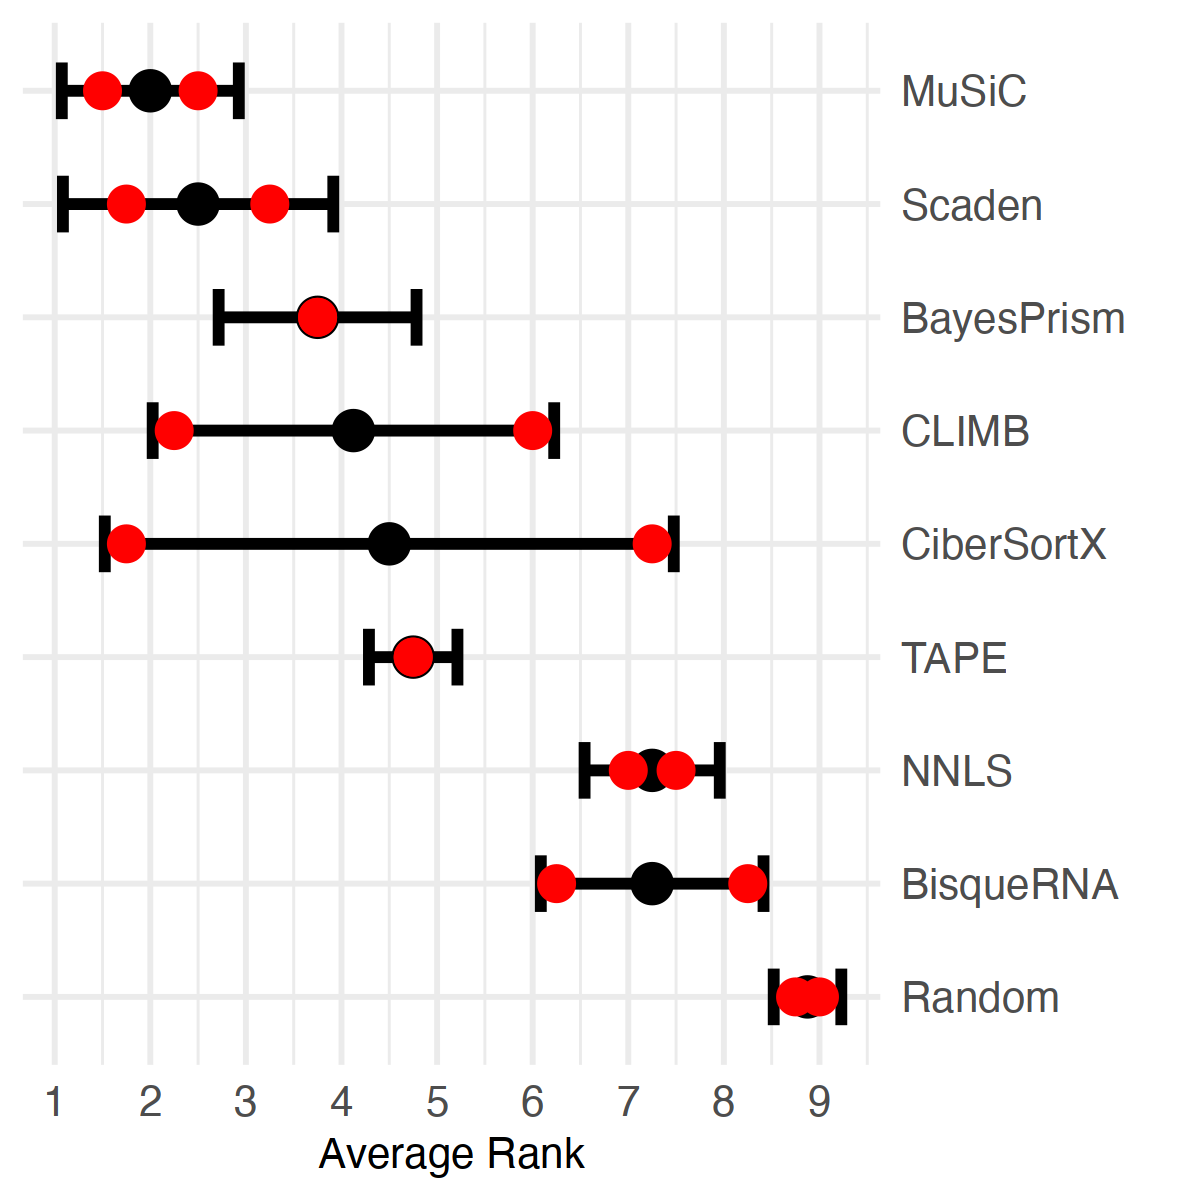

In [49]:
df_all.mel = cbind(ranks.gray2wu, ranks.wu2gray)
mat_ranks = as.matrix(df_all.mel)
df_all.mel$mean_overall = rowMeans(mat_ranks)
df_all.mel$std_overall = rowSds(mat_ranks)
df_all.mel$mean_inter1 = rowMeans(as.matrix(ranks.gray2wu))
df_all.mel$mean_inter2 = rowMeans(as.matrix(ranks.wu2gray))
df_all.mel$method = rownames(df_all.mel)
df_all.mel$method = factor(df_all.mel$method, levels=rev(df_all.mel$method[order(df_all.mel$mean_overall)]))
df_all.mel = df_all.mel[,(dim(df_all.mel)[2]-10):dim(df_all.mel)[2]]
options(repr.plot.width=4, repr.plot.height=4)
ggplot() + geom_errorbar(data=df_all.mel, aes(y=method, xmin=mean_overall-std_overall, xmax=mean_overall+std_overall), width=0.5, size=1, color="black") +
    geom_point(data=df_all.mel, aes(x=mean_overall, y=method), size=4.0, color='black') + 
    geom_point(data=df_all.mel, aes(x=mean_inter1, y=method), size=3.5, color='red') +
    geom_point(data=df_all.mel, aes(x=mean_inter2, y=method), size=3.5, color='red') +
    scale_x_continuous(breaks=1:9) + 
    theme_minimal() + theme(axis.text=element_text(size = 10), text=element_text(size = 10)) + xlab('Average Rank') +
    ylab('') + scale_y_discrete(position = "right")

# Glioblastome (GBM)

In the Glioblastoma analysis, we used two single-cell sequencing from the same dataset, Neftel et al., that have been sequenced by SmartSeq2 and 10x technology. Thus, it is more a "cross-technology" analysis. 
- Neftel (10X) > Neftel (SmartSeq2) (GBM): Cross-technology pseudo-bulk analysis where the scRNA-seq dataset from 10X was used as a reference to deconvolute the pseudo-bulks made from SmartSeq2 dataset, after data integration and transfering of cell subtype labels from 10X to SmartSeq2.
- Neftel (SmartSeq2) > Neftel (10X) (GBM): Cross-technology pseudo-bulk analysis where the scRNA-seq dataset from SmartSeq2 was used as a reference to deconvolute the pseudo-bulks made from 10X dataset, after data integration. Only the 10X dataset had available cell subtype labels, they were thus used on the SmartSeq2 data.

In [50]:
out_dir = 'data/pseudobulks_climb/GBM_SS2tenX'
gbm.ss2tenx = make_all_metrics(load_all_props(out_dir, include_cibersortx = T), paste0(out_dir, '/true_prop.csv'))
out_dir = 'data/pseudobulks_climb/GBM_10x2ss2'
gbm.tenx2ss = make_all_metrics(load_all_props(out_dir, include_cibersortx = T), paste0(out_dir, '/true_prop.csv'))
ranks.ss2tenx = rank_all_metrics(gbm.ss2tenx)
ranks.tenx2ss = rank_all_metrics(gbm.tenx2ss)

Checking that all tables have the same cell-type labels: TRUE

Checking that all tables has the same sample names: TRUE

Checking that all tables have the same cell-type labels: TRUE

Checking that all tables has the same sample names: TRUE



No id variables; using all as measure variables

No id variables; using all as measure variables

No id variables; using all as measure variables

No id variables; using all as measure variables



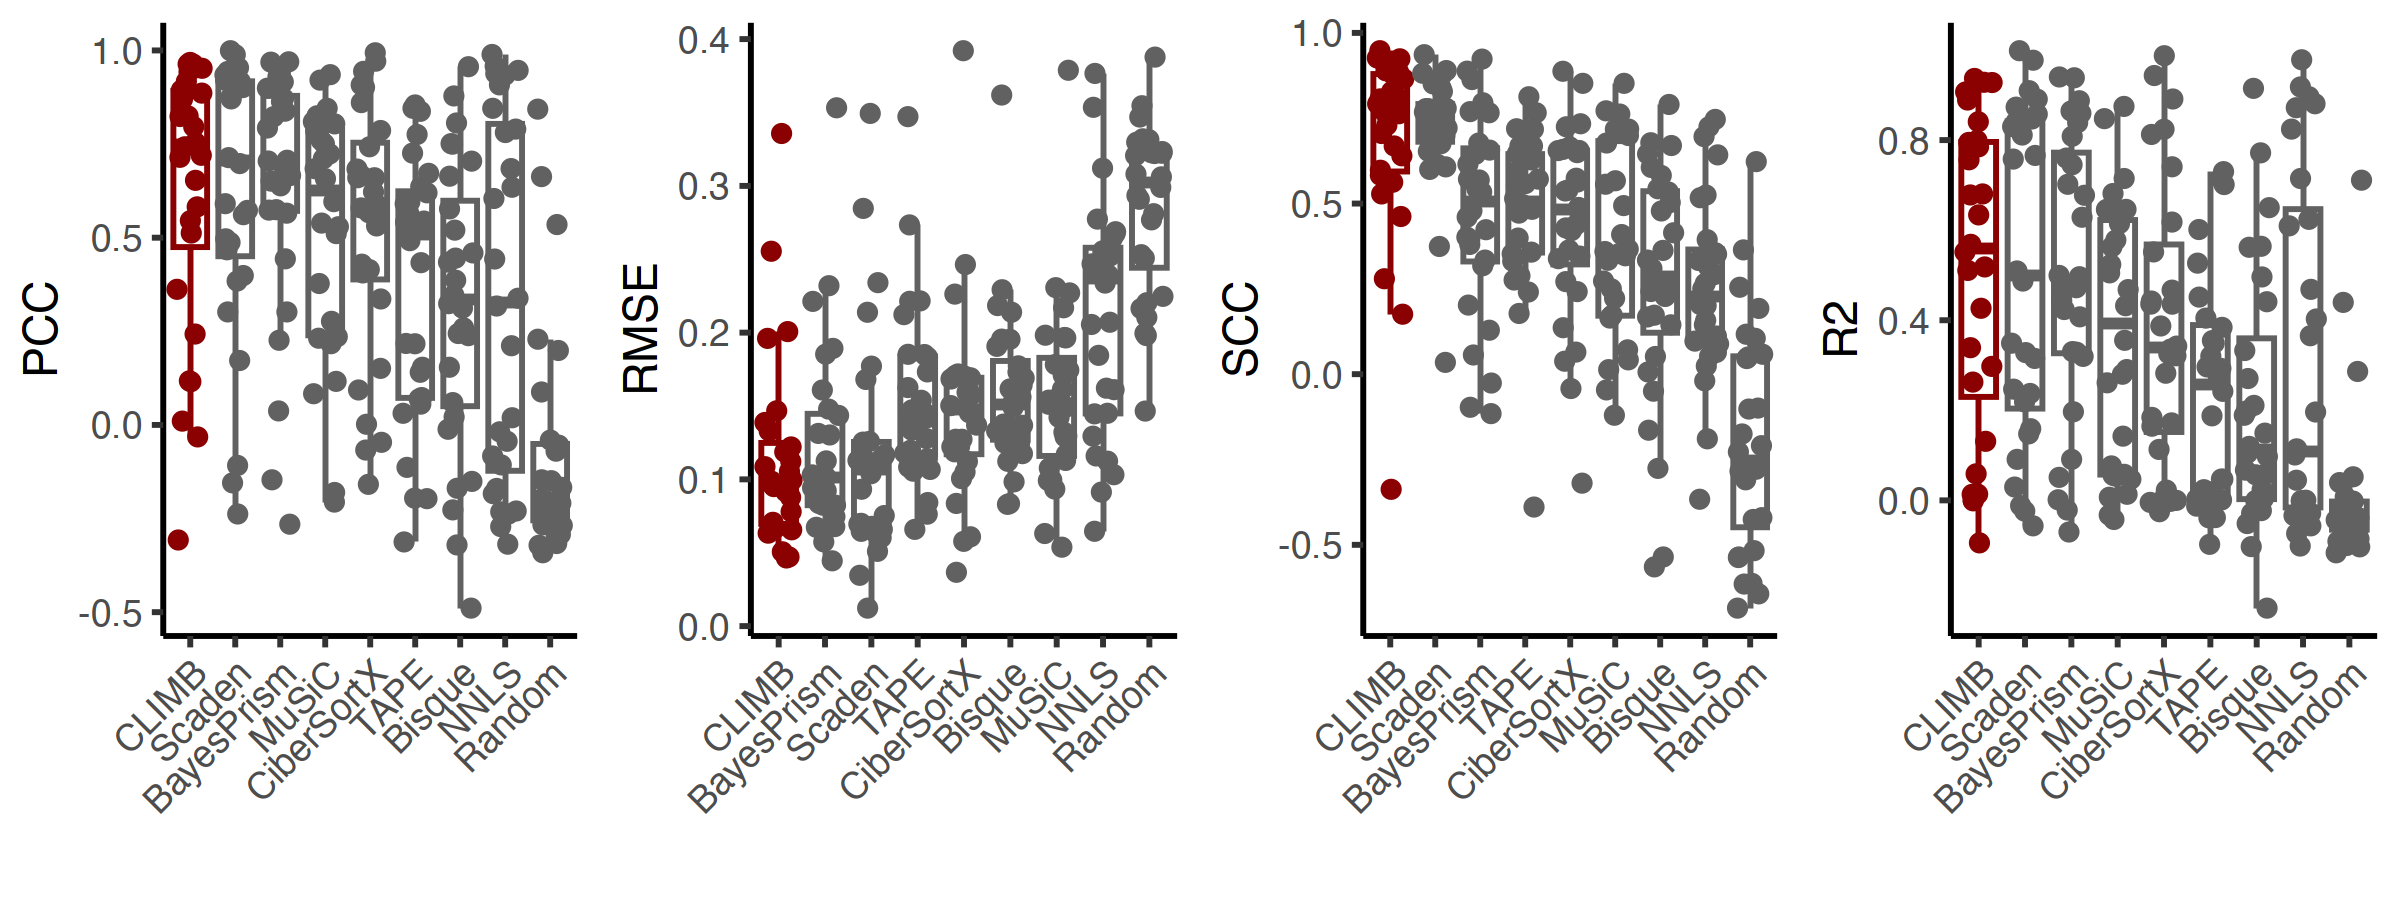

In [51]:
# 10x > SmartSeq2 analysis
g_pcc = generate_comp_plot(gbm.tenx2ss, type.err='PCC_per_sample') # PCC
g_scc = generate_comp_plot(gbm.tenx2ss, type.err='SCC_per_sample') # SCC
g_r2 = generate_comp_plot(gbm.tenx2ss, type.err='R2_per_sample') # R-square
g_rmse = generate_comp_plot(gbm.tenx2ss, type.err='RMSE_per_sample') # RMSE
options(repr.plot.width=8, repr.plot.height=3)
ggarrange(g_pcc, g_rmse, g_scc, g_r2, ncol=4, nrow=1)

No id variables; using all as measure variables

No id variables; using all as measure variables

No id variables; using all as measure variables

No id variables; using all as measure variables



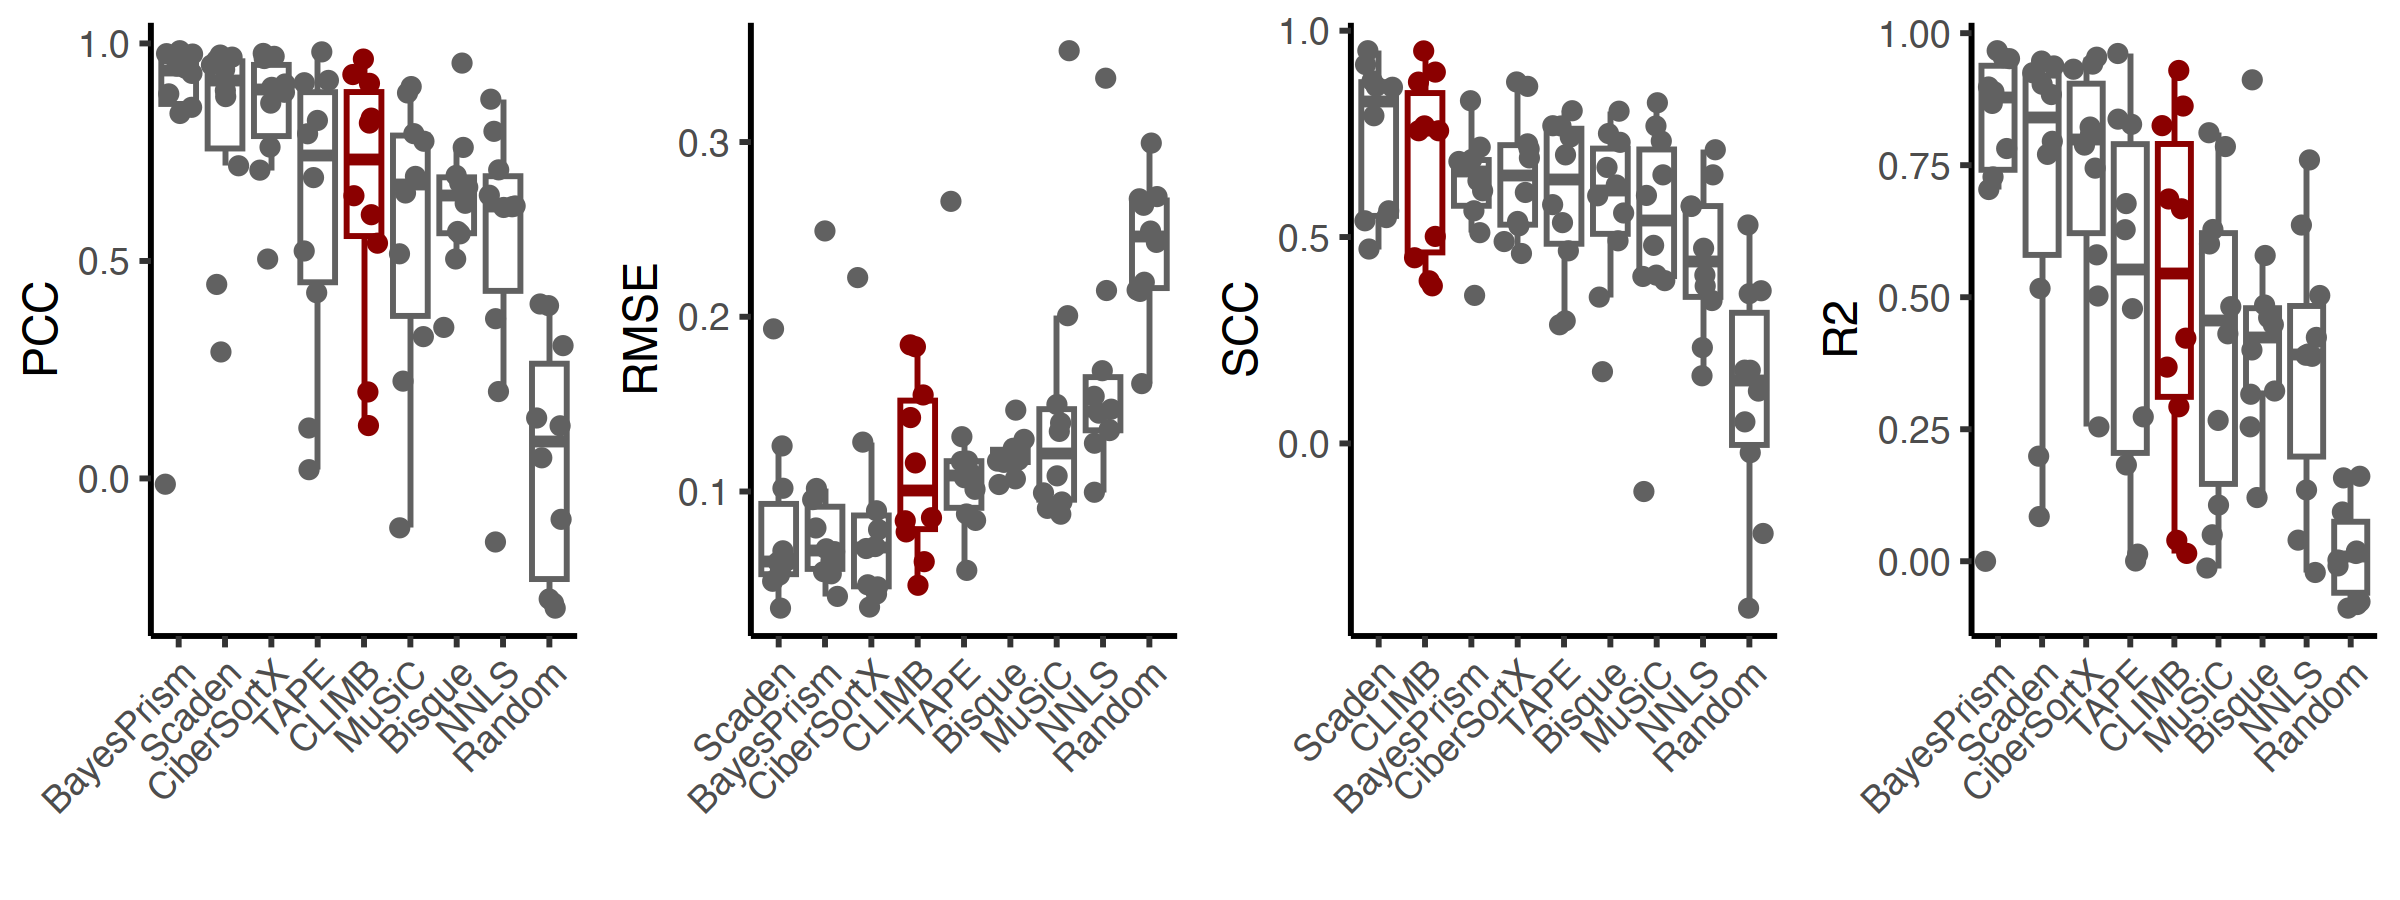

In [52]:
# SmartSeq2 > 10X analysis
g_pcc = generate_comp_plot(gbm.ss2tenx, type.err='PCC_per_sample') # PCC
g_scc = generate_comp_plot(gbm.ss2tenx, type.err='SCC_per_sample') # SCC
g_r2 = generate_comp_plot(gbm.ss2tenx, type.err='R2_per_sample') # R-square
g_rmse = generate_comp_plot(gbm.ss2tenx, type.err='RMSE_per_sample') # RMSE
options(repr.plot.width=8, repr.plot.height=3)
ggarrange(g_pcc, g_rmse, g_scc, g_r2, ncol=4, nrow=1)

Assembling rankings from both analysis :

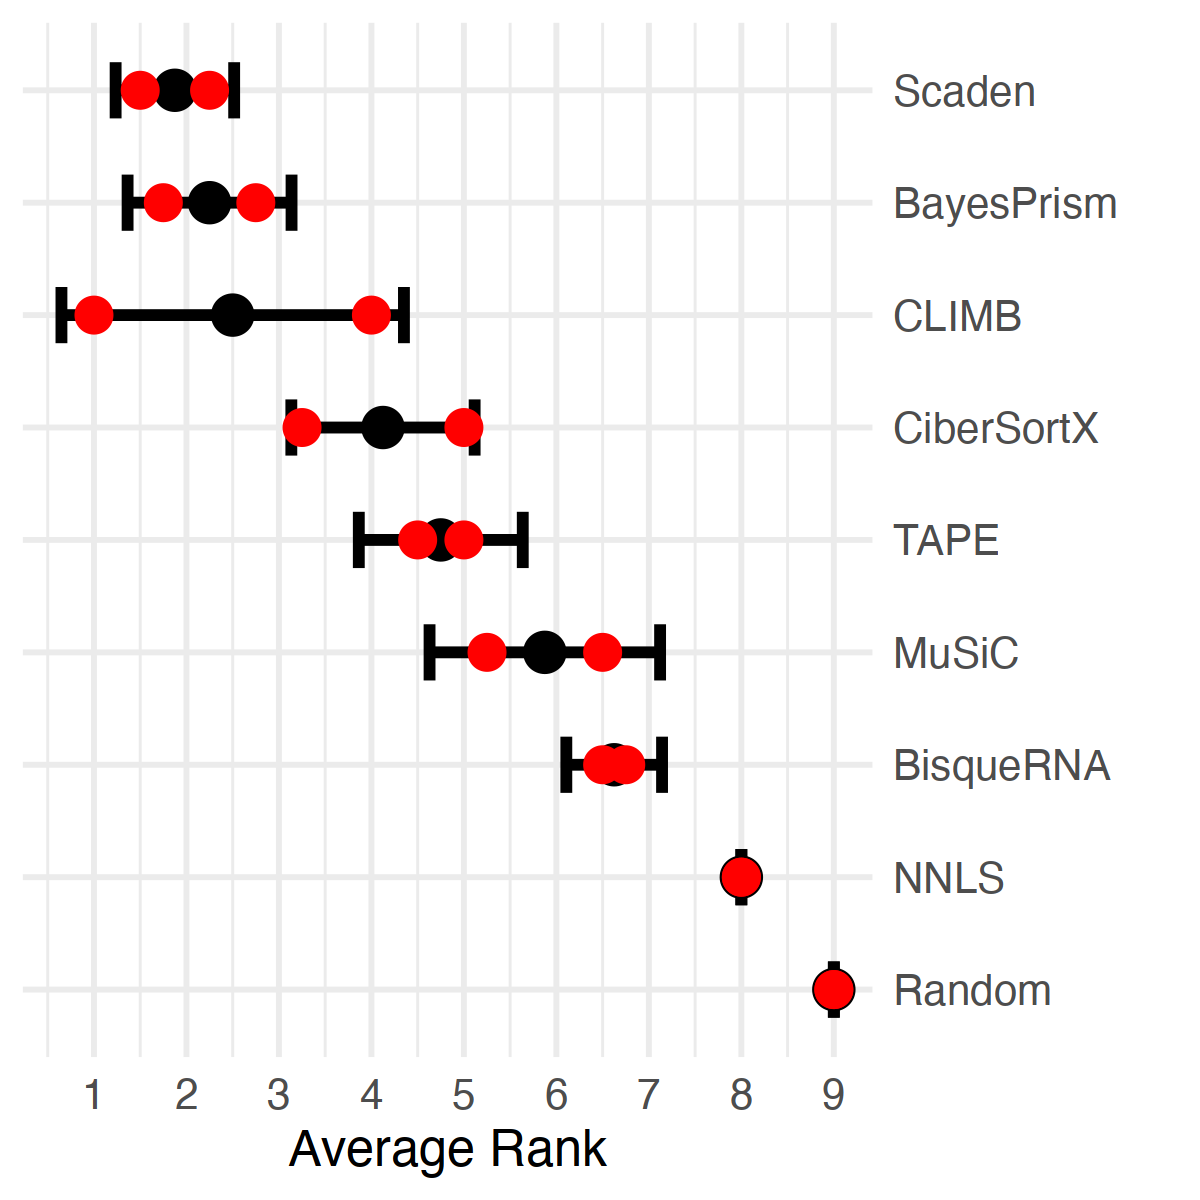

In [53]:
mat_ranks = as.matrix(cbind(ranks.ss2tenx, ranks.tenx2ss))
df_all.mel$mean_overall = rowMeans(mat_ranks)
df_all.mel$std_overall = rowSds(mat_ranks)
df_all.mel$mean_inter1 = rowMeans(as.matrix(ranks.ss2tenx))
df_all.mel$mean_inter2 = rowMeans(as.matrix(ranks.tenx2ss))
df_all.mel$method = rownames(df_all.mel)
df_all.mel$method = factor(df_all.mel$method, levels=rev(df_all.mel$method[order(df_all.mel$mean_overall)]))
df_all.mel = df_all.mel[,(dim(df_all.mel)[2]-10):dim(df_all.mel)[2]]
options(repr.plot.width=4, repr.plot.height=4)
ggplot() + geom_errorbar(data=df_all.mel, aes(y=method, xmin=mean_overall-std_overall, xmax=mean_overall+std_overall), width=0.5, size=1, color="black") +
    geom_point(data=df_all.mel, aes(x=mean_overall, y=method), size=4.0, color='black') + 
    geom_point(data=df_all.mel, aes(x=mean_inter1, y=method), size=3.5, color='red') +
    geom_point(data=df_all.mel, aes(x=mean_inter2, y=method), size=3.5, color='red') +
    scale_x_continuous(breaks=1:9) + 
    theme_minimal() + theme(axis.text=element_text(size = 10), text=element_text(size = 12)) + xlab('Average Rank') +
    ylab('') + scale_y_discrete(position = "right")

# Assemble all analysis in one figure

Here we assemble the rankings from 12 analysis described in the 2nd cell of this notebook, using 4 metrics.

In [54]:
# Assemble all ranks from 12 analysis in a single matrix of rank:
mat_ranks = as.matrix(cbind(ranks.vg2na, ranks.na2vg, ranks.vg2na_200sim, ranks.invitro, # AML comparison
                     ranks.kha2lee, ranks.lee2kha, # CRC comparison
                     ranks.jer2tir, ranks.tir2jer, # MEL comparison
                     ranks.gray2wu, ranks.wu2gray, # BREAST comparison
                     ranks.ss2tenx, ranks.tenx2ss)) # GBM comparison

In [59]:
# Compute the average for each analysis, and the global standard deviation:
df_all.merge = data.frame(mean_overall = rowMeans(mat_ranks))
df_all.merge$std_overall = rowSds(mat_ranks)
df_all.merge$vg2na = rowMeans(as.matrix(ranks.vg2na))
df_all.merge$na2vg = rowMeans(as.matrix(ranks.na2vg))
df_all.merge$na2vg_200sim = rowMeans(as.matrix(ranks.vg2na_200sim))
df_all.merge$invitro = rowMeans(as.matrix(ranks.invitro))
df_all.merge$kha2lee = rowMeans(as.matrix(ranks.kha2lee))
df_all.merge$lee2kha = rowMeans(as.matrix(ranks.lee2kha))
df_all.merge$jer2tir = rowMeans(as.matrix(ranks.jer2tir))
df_all.merge$tir2jer = rowMeans(as.matrix(ranks.tir2jer))
df_all.merge$gray2wu = rowMeans(as.matrix(ranks.gray2wu))
df_all.merge$wu2gray = rowMeans(as.matrix(ranks.wu2gray))
df_all.merge$ss2tenx = rowMeans(as.matrix(ranks.ss2tenx))
df_all.merge$tenx2ss = rowMeans(as.matrix(ranks.tenx2ss))
rownames(mat_ranks) = rownames(df_all.merge)
df_all.merge$method = rownames(df_all.merge)
df_all.merge$method = factor(df_all.merge$method, levels=rev(df_all.merge$method[order(df_all.merge$mean_overall)][c(2,1,3:9)]))

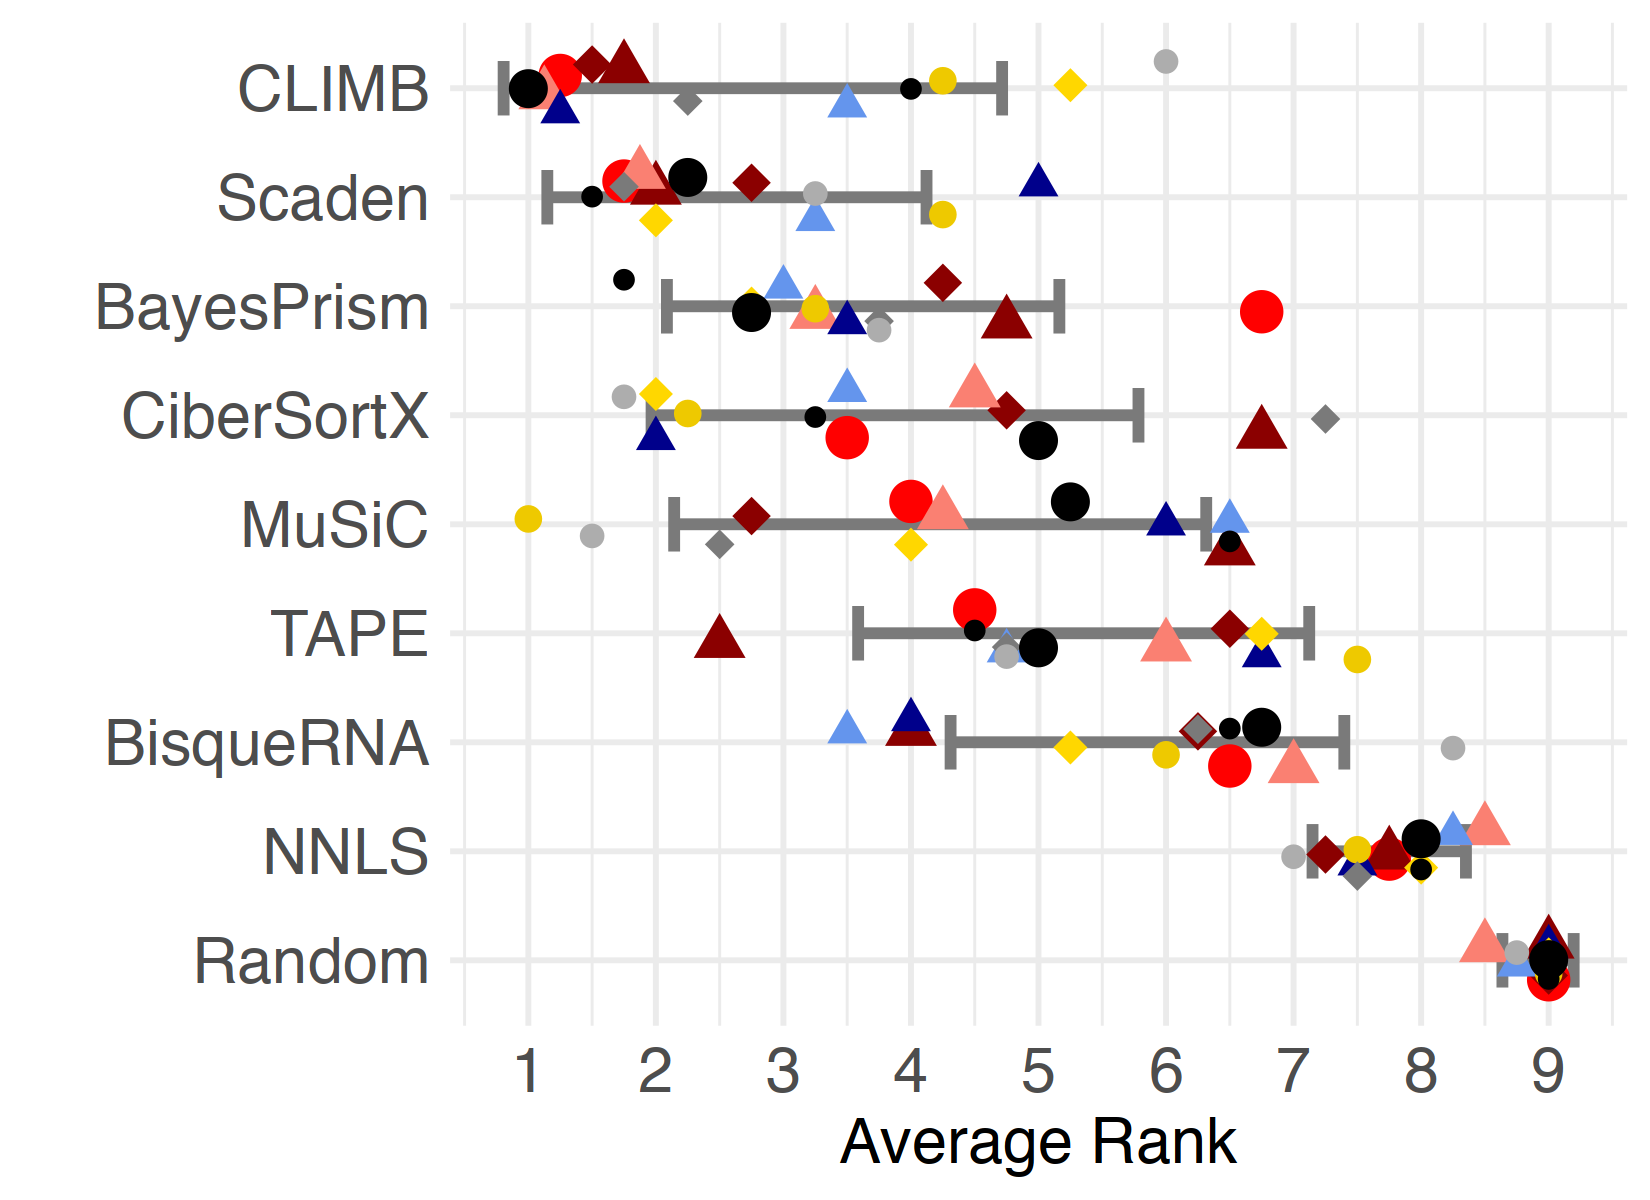

In [56]:
options(repr.plot.width=5.5, repr.plot.height=4)
ggplot(data=df_all.merge) + 
    geom_errorbar(aes(y=method, xmin=mean_overall-std_overall, xmax=mean_overall+std_overall), width=0.5, size=1, color="grey48") +
    #geom_point(aes(x=mean_overall, y=method), size=5.0, color='grey28') + 
    geom_point(aes(x=vg2na, y=method), position = position_jitter(w = 0, h = 0.25), size=4, color='red') + 
    geom_point(aes(x=na2vg, y=method), position = position_jitter(w = 0, h = 0.25), size=4, color='darkred', shape=17)+
    geom_point(aes(x=na2vg_200sim, y=method), position = position_jitter(w = 0, h = 0.25), size=4, color='darkred', shape=18)+
    geom_point(aes(x=invitro, y=method), position = position_jitter(w = 0, h = 0.25), size=4, color='salmon', shape=17)+
    geom_point(aes(x=kha2lee, y=method), position = position_jitter(w = 0, h = 0.25), size=3, color='cornflowerblue', shape=17)+
    geom_point(aes(x=lee2kha, y=method), position = position_jitter(w = 0, h = 0.25), size=3, color='darkblue', shape=17)+
    geom_point(aes(x=jer2tir, y=method), position = position_jitter(w = 0, h = 0.25), size=3.5, color='gold1', shape=18)+
    geom_point(aes(x=tir2jer, y=method), position = position_jitter(w = 0, h = 0.25), size=3.5, color='gold2', shape=20)+
    geom_point(aes(x=gray2wu, y=method), position = position_jitter(w = 0, h = 0.25), size=3, color='grey48', shape=18)+
    geom_point(aes(x=wu2gray, y=method), position = position_jitter(w = 0, h = 0.25), size=3, color='grey68', shape=20)+
    geom_point(aes(x=ss2tenx, y=method), position = position_jitter(w = 0, h = 0.25), size=2.5, color='black', shape=20)+
    geom_point(aes(x=tenx2ss, y=method), position = position_jitter(w = 0, h = 0.25), size=3.5, color='black', shape=19)+
    scale_x_continuous(breaks=1:9) + 
    theme_minimal() + theme(axis.text=element_text(size = 15), text=element_text(size = 15)) + xlab('Average Rank') +
    ylab('') + scale_y_discrete(position = "left")

We then compute statistics comparing CLIMB with every other methods:

In [63]:
print_ranks <- function(rank_matrix){
    print(paste0(rownames(rank_matrix[2,]), ' p-value: ',
        suppressWarnings(wilcox.test(num(rank_matrix[1,]), num(rank_matrix[2,]))$p.value)))
    print(paste0(rownames(rank_matrix[3,]), ' p-value: ',
        suppressWarnings(wilcox.test(num(rank_matrix[1,]), num(rank_matrix[3,]))$p.value)))
    print(paste0(rownames(rank_matrix[4,]), ' p-value: ',
        suppressWarnings(wilcox.test(num(rank_matrix[1,]), num(rank_matrix[4,]))$p.value)))
    print(paste0(rownames(rank_matrix[5,]), ' p-value: ',
        suppressWarnings(wilcox.test(num(rank_matrix[1,]), num(rank_matrix[5,]))$p.value)))
    print(paste0(rownames(rank_matrix[6,]), ' p-value: ',
        suppressWarnings(wilcox.test(num(rank_matrix[1,]), num(rank_matrix[6,]))$p.value)))
    print(paste0(rownames(rank_matrix[7,]), ' p-value: ',
        suppressWarnings(wilcox.test(num(rank_matrix[1,]), num(rank_matrix[7,]))$p.value)))
    print(paste0(rownames(rank_matrix[8,]), ' p-value: ',
        suppressWarnings(wilcox.test(num(rank_matrix[1,]), num(rank_matrix[8,]))$p.value)))
}
print_ranks(data.frame(mat_ranks))

[1] "Scaden p-value: 0.556863009703968"
[1] "TAPE p-value: 4.94380813344345e-08"
[1] "CiberSortX p-value: 0.00307751008690209"
[1] "BayesPrism p-value: 0.00976638308124651"
[1] "MuSiC p-value: 0.000886331476778905"
[1] "NNLS p-value: 1.08581085802397e-17"
[1] "BisqueRNA p-value: 1.16192450087394e-10"
